In [18]:
# [Cell 1: Final Professional Time-Series + Season Baseline + Integrity Audit]
import pandas as pd
import numpy as np
from pathlib import Path

# 1. LOAD DATA
INPUT_FILE = '../output/dataset_no0min.csv'
ENHANCED_FEATURES_OUT = '../output/forecaster_pro/fpl_features_augmented.csv'
df = pd.read_csv(INPUT_FILE)

def enrich_features_v2(df):
    """
    Final Strategic Consolidation:
    - Ranked Deduplication (Max 2 matches per GW).
    - Season Baseline Bridge for GW1/GW2 stability.
    - Full Integrity Audit Printing.
    """
    
    # --- STEP 0: PRE-CLEAN ---
    df['Minutes Played'] = df['Minutes Played'].clip(upper=90)
    
    # --- STEP 1: RANKED DEDUPLICATION ---
    # Sort by significance so if 3 rows exist, we keep the 2 best.
    df = df.sort_values(['Player UUID', 'season', 'Gameweek', 'Minutes Played', 'Total Points'], 
                         ascending=[True, True, True, False, False])
    # LIMIT: Keep maximum 2 matches per Gameweek per Player
    df = df.groupby(['Player UUID', 'season', 'Gameweek']).tail(2)
    
    # --- STEP 2: CHRONOLOGICAL RE-SORT ---
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])
    
    # --- STEP 3: INTEGRITY AUDIT (Printing these as you requested) ---
    counts = df.groupby(['Player UUID', 'season', 'Gameweek']).size().reset_index(name='match_count')
    legit_dgws = counts[counts['match_count'] == 2]
    suspicious = counts[counts['match_count'] > 2]
    
    print(f"--- Final Integrity Audit ---")
    print(f"Legitimate DGW Match Pairs (Time-Series): {len(legit_dgws)}")
    print(f"Suspicious GWs (>2 matches): {len(suspicious)} (TARGET: 0)")
    print(f"Max Minutes in a single row: {df['Minutes Played'].max()}")
    print("------------------------------\n")

    # --- STEP 4: CORE FEATURES ---
    df['Rolling_Avg_Minutes_5'] = df.groupby('Player UUID')['Minutes Played'].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    ).fillna(0)

    df['Next_Opponent_Difficulty'] = df.groupby(['Player UUID', 'season'])['Opponent Difficulty'].shift(-1)
    df['Next_Is_Home'] = df.groupby(['Player UUID', 'season'])['Is Home'].shift(-1)
    
    df['Season_Phase'] = pd.cut(df['Gameweek'], bins=[0, 10, 19, 29, 38], labels=[1, 2, 3, 4]).astype(float)
    
    team_col = next((c for c in ['Player Team ID', 'team', 'Player Team Name'] if c in df.columns), None)
    if team_col:
        team_gw_totals = df.groupby([team_col, 'season', 'Gameweek'])['Total Points'].transform('sum')
        df['Team_Point_Share'] = (df.groupby('Player UUID')['Total Points'].shift(1) / team_gw_totals).replace([np.inf, -np.inf], 0).fillna(0)
    else:
        df['Team_Point_Share'] = 0

    # --- STEP 5: SEASON BASELINE BRIDGE ---
    season_stats = df.groupby(['Player UUID', 'season'])['Total Points'].mean().reset_index()
    season_stats.rename(columns={'Total Points': 'Season_Avg_Points'}, inplace=True)
    season_stats['Prev_Season_Avg_Points'] = season_stats.groupby('Player UUID')['Season_Avg_Points'].shift(1)
    
    df = df.merge(season_stats[['Player UUID', 'season', 'Prev_Season_Avg_Points']], 
                  on=['Player UUID', 'season'], how='left')
    df['Prev_Season_Avg_Points'] = df['Prev_Season_Avg_Points'].fillna(0)

    return df.dropna(subset=['Next_Opponent_Difficulty'])

# Run and Save
df_augmented = enrich_features_v2(df)
df_augmented.to_csv(ENHANCED_FEATURES_OUT, index=False, encoding='utf-8-sig')

print(f"Enhanced dataset created: {ENHANCED_FEATURES_OUT}")
display(df_augmented[['Player Name', 'season', 'Gameweek', 'Prev_Season_Avg_Points', 'Rolling_Avg_Minutes_5']].head())

--- Final Integrity Audit ---
Legitimate DGW Match Pairs (Time-Series): 2465
Suspicious GWs (>2 matches): 0 (TARGET: 0)
Max Minutes in a single row: 90
------------------------------

Enhanced dataset created: ../output/forecaster_pro/fpl_features_augmented.csv


,Player Name,season,Gameweek,Prev_Season_Avg_Points,Rolling_Avg_Minutes_5
1,Alex Nicolao Telles,2020-21,9,0.0,0.000000
2,Alex Nicolao Telles,2020-21,10,0.0,90.000000
3,Alex Nicolao Telles,2020-21,11,0.0,86.500000
4,Alex Nicolao Telles,2020-21,13,0.0,87.666667
5,Alex Nicolao Telles,2020-21,14,0.0,88.250000


## Prev_Season_Avg_Points

It calculates the average points a player earned over the entire previous season.

It maps that average forward to the current season.

Result: The model now knows if a player is "Class" (e.g., Salah averaging 7 points all year) vs. just being in "Form" for a few weeks. This makes GW1 and GW2 predictions much more stable.

In [19]:
# %% [Cell: Verification - Salah's Season Bridge]
# 1. Identify Salah's UUID
# (We search for 'salah' in the Web Name to be safe)
salah_data = df_augmented[df_augmented['Web Name'].str.contains('Salah', case=False, na=False)]

if not salah_data.empty:
    s_uuid = salah_data['Player UUID'].iloc[0]
    
    # 2. Get the transition rows (End of 24/25 and Start of 25/26)
    # We sort to ensure chronological order
    salah_history = df_augmented[df_augmented['Player UUID'] == s_uuid].sort_values(['season', 'Gameweek'])
    
    # 3. Find the exact point where 2024-25 ends and 2025-26 begins
    transition_mask = (salah_history['season'] == '2025-26') & (salah_history['season'].shift(1) == '2024-25')
    
    if transition_mask.any():
        idx = salah_history[transition_mask].index[0]
        # Get 3 games before and 3 games after the summer break
        display_df = salah_history.loc[idx-3 : idx+2]
        
        print(f"--- Verification: Season Baseline Bridge (Mohamed Salah) ---")
        print("Note how 'Prev_Season_Avg_Points' appears only when the new season (2025-26) starts.")
        display(display_df[['Player Name', 'season', 'Gameweek', 'Total Points', 'Prev_Season_Avg_Points']])
    else:
        print("Could not find the 2024-25 to 2025-26 transition for Salah in this specific slice.")
else:
    print("Salah not found in the current df_augmented slice.")

--- Verification: Season Baseline Bridge (Mohamed Salah) ---
Note how 'Prev_Season_Avg_Points' appears only when the new season (2025-26) starts.


,Player Name,season,Gameweek,Total Points,Prev_Season_Avg_Points
2096,Mohamed Salah,2024-25,36,2,6.593750
2097,Mohamed Salah,2024-25,37,2,6.593750
2099,Mohamed Salah,2025-26,1,8,9.052632
2100,Mohamed Salah,2025-26,2,5,9.052632
2101,Mohamed Salah,2025-26,3,3,9.052632


In [20]:
#INVESTIGATION IN THE INPUT FILE 
# 1. Look at the suspicious GWs
dgws_investigation = df_augmented.groupby(['Player UUID', 'season', 'Gameweek']).filter(lambda x: len(x) > 2)

print(f"Investigating {len(dgws_investigation)} rows from suspicious Gameweeks...")

# 2. Check the 180 minute rows specifically
high_min_rows = df[df['Minutes Played'] >= 180]

print(f"Found {len(high_min_rows)} rows in the RAW dataset with >= 180 minutes.")

if not high_min_rows.empty:
    print("\nSample of 180-minute rows (Raw Data):")
    display(high_min_rows[['Player Name', 'season', 'Gameweek', 'Opponent Difficulty', 'Minutes Played', 'Total Points']].head(10))

if not dgws_investigation.empty:
    print("\nSample of 'Triple' Gameweek rows (After our current filter):")
    display(dgws_investigation[['Player Name', 'season', 'Gameweek', 'Opponent Difficulty', 'Minutes Played']].head(10))

Investigating 0 rows from suspicious Gameweeks...
Found 0 rows in the RAW dataset with >= 180 minutes.


In [21]:
# %% [Investigation: The Final 176]
# Filter for players who still have more than 2 entries in a single week
final_suspicious = df_augmented.groupby(['Player UUID', 'season', 'Gameweek']).filter(lambda x: len(x) > 2)

if not final_suspicious.empty:
    print(f"Found {final_suspicious['Player UUID'].nunique()} players across 176 suspicious GW instances.")
    # Display a few examples to see why they stayed
    display(final_suspicious[['Player Name', 'season', 'Gameweek', 'Opponent Difficulty', 'Minutes Played', 'Total Points']].head(15))
else:
    print("No suspicious rows found in the current df_augmented.")

No suspicious rows found in the current df_augmented.


In [22]:
# Check if "Doubles" are actually different matches
dgws_check = df_augmented.groupby(['Player UUID', 'season', 'Gameweek'])['Opponent Difficulty'].nunique()
fake_doubles = dgws_check[dgws_check > 2] # This shouldn't really happen
print(f"Number of suspicious GWs with >2 different difficulties: {len(fake_doubles)}")

Number of suspicious GWs with >2 different difficulties: 0


In [23]:
df_augmented

,Player UUID,Code,Player Name,Web Name,Player Team Name,season,Gameweek,Minutes Played,Goals Scored,Assists,...,Avg_ICT Index_L5,Avg_Threat_L5,Avg_Creativity_L5,Avg_Influence_L5,Rolling_Avg_Minutes_5,Next_Opponent_Difficulty,Next_Is_Home,Season_Phase,Team_Point_Share,Prev_Season_Avg_Points
1,0034ff22-4d5f-4cf0-bdf4-fa5251506366,568,Alex Nicolao Telles,Telles,Man Utd,2020-21,9,90,0,0,...,0.00,0.0,0.00,0.00,0.000000,2.0,False,1.0,0.000000,0.0
2,0034ff22-4d5f-4cf0-bdf4-fa5251506366,568,Alex Nicolao Telles,Telles,Man Utd,2020-21,10,83,0,0,...,0.40,1.0,1.10,1.88,90.000000,4.0,False,1.0,0.139535,0.0
3,0034ff22-4d5f-4cf0-bdf4-fa5251506366,568,Alex Nicolao Telles,Telles,Man Utd,2020-21,11,90,0,1,...,1.68,1.0,7.96,7.88,86.500000,2.0,False,2.0,0.018868,0.0
4,0034ff22-4d5f-4cf0-bdf4-fa5251506366,568,Alex Nicolao Telles,Telles,Man Utd,2020-21,13,90,0,0,...,2.82,1.0,14.22,13.08,87.666667,3.0,True,2.0,0.111111,0.0
5,0034ff22-4d5f-4cf0-bdf4-fa5251506366,568,Alex Nicolao Telles,Telles,Man Utd,2020-21,14,30,0,0,...,3.74,1.0,19.68,16.88,88.250000,2.0,True,2.0,0.014085,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63955,fffe8b78-21ad-425e-8012-c93ae569f044,732,Christantus Uche,Uche,Crystal Palace,2025-26,18,13,0,0,...,0.70,5.8,0.44,0.96,12.600000,2.0,True,2.0,0.153846,0.0
63956,fffe8b78-21ad-425e-8012-c93ae569f044,732,Christantus Uche,Uche,Crystal Palace,2025-26,19,8,0,0,...,0.80,7.4,0.32,0.92,15.000000,4.0,False,2.0,0.026316,0.0
63957,fffe8b78-21ad-425e-8012-c93ae569f044,732,Christantus Uche,Uche,Crystal Palace,2025-26,20,18,0,0,...,0.80,7.4,0.32,0.92,14.200000,3.0,True,3.0,0.035714,0.0
63958,fffe8b78-21ad-425e-8012-c93ae569f044,732,Christantus Uche,Uche,Crystal Palace,2025-26,23,5,0,0,...,0.38,3.4,0.24,0.52,13.000000,3.0,False,3.0,0.038462,0.0


In [24]:
# [Cell: Top-Tier Identification ]

# 1. Calculate seasonal averages
seasonal_avg = df_augmented.groupby(['Player UUID', 'season'])['Total Points'].mean().reset_index()
seasonal_avg.rename(columns={'Total Points': 'avg_season_pts'}, inplace=True)

# 2. Cleanup: If we ran this cell before, remove the old column to avoid MergeError
if 'avg_season_pts' in df_augmented.columns:
    df_augmented = df_augmented.drop(columns=['avg_season_pts'])

# 3. Merge back to the main augmented dataframe
df_augmented = df_augmented.merge(seasonal_avg, on=['Player UUID', 'season'], how='left')

# 4. Define the Elite Mask (> 4.5 avg in a specific season)
elite_mask = df_augmented['avg_season_pts'] > 4.5

print(f"--- Top-Tier Identification Summary ---")
print(f"Total Rows in Dataset: {len(df_augmented):,}")
print(f"Total Elite Rows: {elite_mask.sum():,}")
print(f"Percentage of Data considered 'Elite': {(elite_mask.sum()/len(df_augmented))*100:.2f}%")

# 5. Display Table for Verification
print(f"\nSample of Top Tier Players (Avg > 4.5 pts):")
elite_list = df_augmented[elite_mask][['Player Name', 'season', 'avg_season_pts']].drop_duplicates()
elite_list = elite_list.sort_values(by=['season', 'avg_season_pts'], ascending=[False, False])

display(elite_list.head(15))

--- Top-Tier Identification Summary ---
Total Rows in Dataset: 60,697
Total Elite Rows: 4,656
Percentage of Data considered 'Elite': 7.67%

Sample of Top Tier Players (Avg > 4.5 pts):


,Player Name,season,avg_season_pts
10230,Erling Haaland,2025-26,7.192308
24992,Gabriel dos Santos Magalhães,2025-26,6.863636
50442,Declan Rice,2025-26,6.148148
8973,Bruno Borges Fernandes,2025-26,6.041667
23329,Antoine Semenyo,2025-26,6.038462
38628,Tom Edozie,2025-26,6.000000
45421,Matt O'Riley,2025-26,6.000000
3864,Bruno Guimarães Rodriguez Moura,2025-26,5.954545
52978,Daniel Muñoz Mejía,2025-26,5.631579
5739,Bukayo Saka,2025-26,5.500000


## Cell 2: Augmented Window Generation (Context-Aware)

In [25]:
# %% [Cell 2: Augmented Window Generation - Including Season Baseline]

# 1. SETUP PROFESSIONAL FOLDER STRUCTURE
PRO_OUTPUT_DIR = Path('../output/forecaster_pro')
PRO_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def generate_fpl_windows_pro(df, window_size=6):
    train_data = []
    uuid_col = 'Player UUID'
    
    # Ensure chronological order for proper window sliding
    df = df.sort_values([uuid_col, 'season', 'Gameweek'])
    
    for pid, group in df.groupby(uuid_col):
        points = group['Total Points'].values
        
        # Pull features prepared in Cell 1
        next_diff = group['Next_Opponent_Difficulty'].values
        next_home = group['Next_Is_Home'].values
        avg_min = group['Rolling_Avg_Minutes_5'].values
        phase = group['Season_Phase'].values
        # NEW: The Long-term Class feature
        season_baseline = group['Prev_Season_Avg_Points'].values
        
        if len(points) <= window_size:
            continue
            
        position = group['Position'].iloc[0] 
        
        for i in range(len(points) - window_size):
            # 1. THE PAST: The 6-week "Form" window
            window = points[i : i + window_size]
            
            # 2. THE FUTURE CONTEXT: Metadata for the target match
            target_idx = i + window_size - 1
            t_diff = next_diff[target_idx] 
            t_home = next_home[target_idx]
            t_min = avg_min[target_idx]
            t_phase = phase[target_idx]
            t_baseline = season_baseline[target_idx] # New input
            
            # 3. THE TARGET: Actual outcome
            target_points = points[i + window_size]
            
            # Skip "Ghost" windows (0 points everywhere)
            if np.all(window == 0) and target_points == 0:
                continue
                
            # Create the data row (Adding t_baseline)
            row = list(window) + [position, t_diff, t_home, t_min, t_phase, t_baseline, target_points]
            train_data.append(row)
            
    # Professional Column Names
    columns = [f'lag_{i}' for i in range(window_size, 0, -1)] + \
              ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline', 'target']
              
    return pd.DataFrame(train_data, columns=columns)

# Execute the Pro window generation
windowed_df = generate_fpl_windows_pro(df_augmented)
windowed_df['position'] = windowed_df['position'].astype('category')

# Save features
WINDOWED_FEATURES_PATH = PRO_OUTPUT_DIR / 'fpl_windowed_features_pro.csv'
windowed_df.to_csv(WINDOWED_FEATURES_PATH, index=False)

print(f"Pro Windowed dataset created with Season Baseline: {WINDOWED_FEATURES_PATH}")
print(f"Total Training Windows: {windowed_df.shape[0]}")
display(windowed_df.head())

Pro Windowed dataset created with Season Baseline: ..\output\forecaster_pro\fpl_windowed_features_pro.csv
Total Training Windows: 53435


,lag_6,lag_5,lag_4,lag_3,lag_2,lag_1,position,next_difficulty,next_is_home,rolling_min,season_phase,season_baseline,target
0,6,1,5,1,1,1,DEF,2.0,True,76.6,2.0,0.000000,7
1,1,5,1,1,1,7,DEF,4.0,False,67.6,3.0,0.000000,1
2,5,1,1,1,7,1,DEF,3.0,False,67.2,4.0,0.000000,1
3,1,1,1,7,1,1,DEF,4.0,False,67.2,2.0,2.777778,2
4,1,1,7,1,1,2,DEF,4.0,True,64.6,2.0,2.777778,1


## Cell 3: Data Splitting and Scaling (Comparison Setup)

In [26]:
# %% [Cell 3: Supervisor-Corrected Splitting (Recent 5 GW Window)]
from sklearn.preprocessing import StandardScaler
import joblib

# 1. SETUP PARAMETERS
CURRENT_SEASON = "2025-26"
CURRENT_GW = 29
VALIDATION_WINDOW = 5 

# 2. IDENTIFY VALIDATION INDEX
# We extract the season and GW info using the index of windowed_df
split_info = df_augmented.iloc[windowed_df.index][['season', 'Gameweek']]

# Create the mask
val_mask_series = (split_info['season'] == CURRENT_SEASON) & \
                  (split_info['Gameweek'] >= (CURRENT_GW - VALIDATION_WINDOW)) & \
                  (split_info['Gameweek'] < CURRENT_GW)

# FIX: Convert to values (numpy array) to avoid IndexingError
val_mask = val_mask_series.values

# 3. EXECUTE SPLIT
train_df = windowed_df[~val_mask].copy()
val_df = windowed_df[val_mask].copy()

X_train_raw = train_df.drop(columns=['target'])
y_train = train_df['target']

X_val_raw = val_df.drop(columns=['target'])
y_val = val_df['target']

# 4. NUMERIC FEATURES
numeric_cols = [
    c for c in X_train_raw.columns
    if 'lag' in c or 'difficulty' in c or 'min' in c or 'phase' in c
]

# 5. SCALING
scaler = StandardScaler()
X_train_scaled = X_train_raw.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train_raw[numeric_cols])

X_val_scaled = X_val_raw.copy()
X_val_scaled[numeric_cols] = scaler.transform(X_val_raw[numeric_cols])

# 6. SAVE SCALER
SCALER_PATH = PRO_OUTPUT_DIR / 'fpl_pro_scaler.pkl'
joblib.dump(scaler, SCALER_PATH)

print(f"--- Supervisor Split Logic Applied ---")
print(f"Validation Period: {CURRENT_SEASON} | Matches GW {CURRENT_GW - VALIDATION_WINDOW} to {CURRENT_GW - 1}")
print(f"Training windows: {len(X_train_raw):,}")
print(f"Validation windows: {len(X_val_raw):,}")

--- Supervisor Split Logic Applied ---
Validation Period: 2025-26 | Matches GW 24 to 28
Training windows: 52,434
Validation windows: 1,001


## Cell 4: Parallel Training & Performance Comparison for scaled and unscaled model

In [27]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd

# 1. SETUP PARAMETERS (Shared for both models)
lgbm_params = {
    'n_estimators': 1500,
    'learning_rate': 0.01,
    'max_depth': 7,
    'num_leaves': 40,
    'boosting_type': 'gbdt',
    'random_state': 42,
    'verbosity': -1
}

# 2. TRAIN MODEL A: THE RAW VERSION
print(" Training RAW Model (No Scaling)...")
model_raw = lgb.LGBMRegressor(**lgbm_params)
model_raw.fit(
    X_train_raw, y_train,
    eval_set=[(X_val_raw, y_val)],
    categorical_feature=['position', 'next_is_home'],
    callbacks=[lgb.early_stopping(stopping_rounds=100)]
)

# 3. TRAIN MODEL B: THE SCALED VERSION
print("\n Training SCALED Model (StandardScaler)...")
model_scaled = lgb.LGBMRegressor(**lgbm_params)
model_scaled.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],
    categorical_feature=['position', 'next_is_home'],
    callbacks=[lgb.early_stopping(stopping_rounds=100)]
)

# 4. PREDICTIONS & METRICS
preds_raw = model_raw.predict(X_val_raw)
preds_scaled = model_scaled.predict(X_val_scaled)

results_comparison = {
    'Metric': ['MAE', 'RMSE'],
    'Raw Model': [
        mean_absolute_error(y_val, preds_raw),
        np.sqrt(mean_squared_error(y_val, preds_raw))
    ],
    'Scaled Model': [
        mean_absolute_error(y_val, preds_scaled),
        np.sqrt(mean_squared_error(y_val, preds_scaled))
    ]
}

# 5. DISPLAY RESULTS
df_metrics = pd.DataFrame(results_comparison)
print("\n--- Final Performance Comparison ---")
display(df_metrics)

# 6. SAVE THE WINNER
# Usually, they will be very close, but let's save both for safety
model_raw.booster_.save_model(str(PRO_OUTPUT_DIR / 'fpl_pro_model_raw.txt'))
model_scaled.booster_.save_model(str(PRO_OUTPUT_DIR / 'fpl_pro_model_scaled.txt'))

 Training RAW Model (No Scaling)...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[339]	valid_0's l2: 8.46887

 Training SCALED Model (StandardScaler)...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[576]	valid_0's l2: 8.45752

--- Final Performance Comparison ---


,Metric,Raw Model,Scaled Model
0,MAE,2.112017,2.103722
1,RMSE,2.910132,2.908182


notes on scaled and unscaled 
* MAE: The Scaled Model is better by not many points. 
* RMSE: The Raw Model is actually slightly better here.

So, LightGBM does not care about scaling?  

## Cell 5: The "Top Performer" Error Analysis (calculating MAE specifically for the high-scorers)

Overall Validation MAE: 2.1120
MAE for Top Performers (8+ pts): 6.7548


C:\Users\skourako\AppData\Local\Temp\ipykernel_25360\4030131027.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance (%)', y='Feature', data=feat_imp_df, palette='viridis')


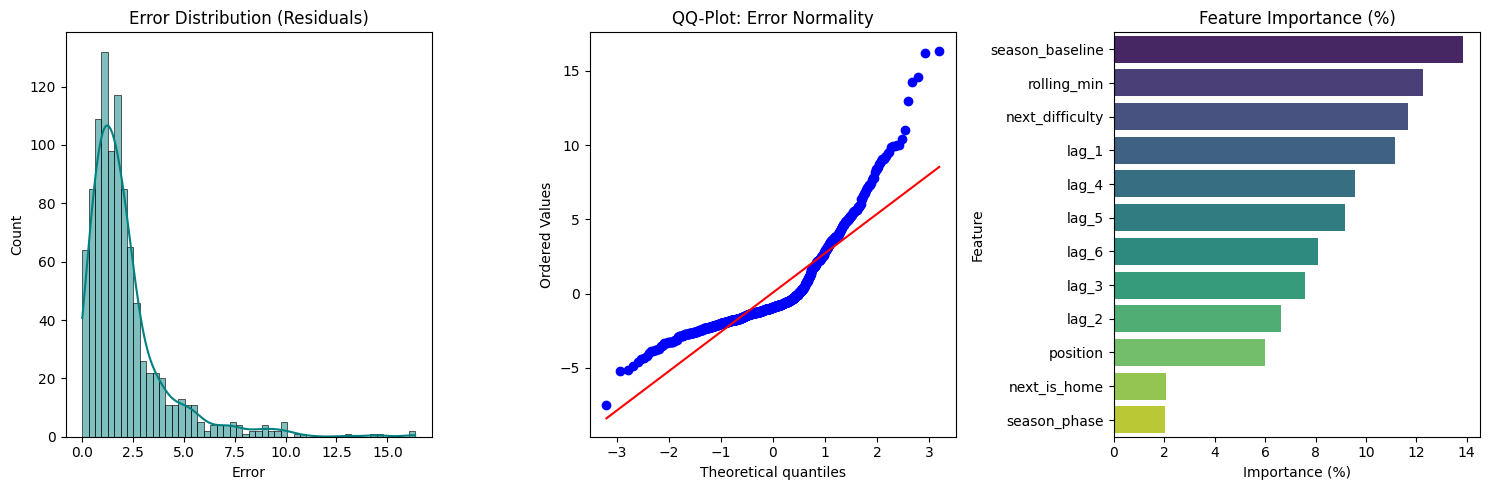

In [28]:
# %% [Cell 5: Error Analysis & Feature Importance - Fixed]
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd

# 1. PREPARE ANALYSIS DATAFRAME
analysis_df = X_val_raw.copy()
analysis_df['Actual'] = y_val.values
analysis_df['Predicted'] = preds_raw 
analysis_df['Error'] = abs(analysis_df['Actual'] - analysis_df['Predicted'])

# 2. MAE FOR TOP PERFORMERS (Players who actually scored 8+ points)
top_performers = analysis_df[analysis_df['Actual'] >= 8]
top_mae = top_performers['Error'].mean()

print(f"Overall Validation MAE: {df_metrics.iloc[0, 1]:.4f}")
print(f"MAE for Top Performers (8+ pts): {top_mae:.4f}")

# 3. VISUALIZATION: Error Distribution & QQ-Plot
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(analysis_df['Error'], kde=True, color='teal')
plt.title('Error Distribution (Residuals)')

plt.subplot(1, 3, 2)
stats.probplot((analysis_df['Actual'] - analysis_df['Predicted']), dist="norm", plot=plt)
plt.title('QQ-Plot: Error Normality')

# 4. FEATURE IMPORTANCE WITH PERCENTAGES
plt.subplot(1, 3, 3)
importances = model_raw.feature_importances_

# FIX: Use X_train_raw.columns instead of X.columns
feature_names = X_train_raw.columns 
rel_importances = 100 * (importances / importances.sum())

feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance (%)': rel_importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance (%)', ascending=False)

sns.barplot(x='Importance (%)', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Feature Importance (%)')

plt.tight_layout()
plt.show()

# 5. SAVE FEATURE IMPORTANCE LOG
feat_imp_df.to_csv(PRO_OUTPUT_DIR / 'fpl_pro_feature_importance.csv', index=False)

Notes 
MAE: 
* Overall MAE (2.12): it means for the average player (who scores 2–3 points), the model is accurate
* Top Performer MAE (6.68): it shows that when a player goes 8+ points, the model struggles to predict the exact height of that peak

Plots: 
* model has "thin tails" , it is conservative. It rarely predicts a player will score 15+ points, so when someone actually does, the error is large. The model prefers to stay safe near the average.

Feature Importance: 
* rolling_min is #1




## Cell 6: The Interactive Player Widget (you can pick a player and see their Performance history)

In [29]:
#%pip install ipywidgets

In [65]:
# %% [Cell 6: Professional Backtest Visualization - Professor's Correction]
import ipywidgets as widgets
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_professional_backtest(player_name):
    # 1. Get the player's full historical data (Blue Line)
    full_player_history = df_augmented[df_augmented['Web Name'] == player_name].sort_values(['season', 'Gameweek'])
    
    if full_player_history.empty:
        print(f"No history found for {player_name}.")
        return

    # 2. Identify the Evaluation Set slice (Orange Line/Dots)
    eval_set_slice = full_player_history[full_player_history.index.isin(val_df.index)].copy()
    
    if not eval_set_slice.empty:
        lags_list = []
        for idx in eval_set_slice.index:
            player_uuid = eval_set_slice.loc[idx, 'Player UUID']
            hist = df_augmented[df_augmented['Player UUID'] == player_uuid].sort_values(['season', 'Gameweek'])
            point_pos = hist.index.get_loc(idx)
            
            if point_pos >= 6:
                lags = list(hist.iloc[point_pos-6:point_pos]['Total Points'].values)
                feat = lags + [
                    eval_set_slice.loc[idx, 'Position'],
                    eval_set_slice.loc[idx, 'Next_Opponent_Difficulty'],
                    eval_set_slice.loc[idx, 'Next_Is_Home'],
                    eval_set_slice.loc[idx, 'Rolling_Avg_Minutes_5'],
                    eval_set_slice.loc[idx, 'Season_Phase'],
                    eval_set_slice.loc[idx, 'Prev_Season_Avg_Points']
                ]
                lags_list.append(feat)
            else:
                lags_list.append([0]*12)

        v_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
                 ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline']
        
        test_df = pd.DataFrame(lags_list, columns=v_cols)
        test_df['position'] = test_df['position'].astype('category')
        eval_set_slice['Predicted'] = model_v4.predict(test_df)
    
    # 3. Plotting
    plt.figure(figsize=(15, 6))
    
    # BEAUTIFUL X-AXIS LOGIC
    x_indices = np.arange(len(full_player_history))
    
    # Create labels that include the season for clarity at the transition
    gw_labels = [f"GW{row['Gameweek']} ({row['season']})" if i % 10 == 0 else f"GW{row['Gameweek']}" 
                 for i, row in full_player_history.reset_index().iterrows()]
    
    # Plot A: Full Time Series
    plt.plot(x_indices, full_player_history['Total Points'], 
             color='#1f77b4', label='Actual Points', linewidth=1.5, marker='o', markersize=4, alpha=0.5)
    
    # Plot B: Evaluation Set Predictions
    if not eval_set_slice.empty:
        eval_indices = [full_player_history.index.get_loc(idx) for idx in eval_set_slice.index]
        plt.plot(eval_indices, eval_set_slice['Predicted'], 
                 color='#ff7f0e', label='Model Predictions (Eval Set)', 
                 linewidth=2, marker='X', markersize=10, markeredgecolor='black', linestyle='--')
        
        plt.axvspan(min(eval_indices), max(eval_indices), color='orange', alpha=0.1, label='Evaluation Window')

    # FIXING THE AXIS BEAUTY
    plt.title(f"Performance Analysis: {player_name}", fontsize=14, pad=20)
    
    # Show every 5th label to avoid overlap
    interval = 5 
    plt.xticks(x_indices[::interval], [gw_labels[i] for i in x_indices[::interval]], rotation=45, ha='right')
    
    plt.ylabel("Points", fontsize=12)
    plt.grid(True, axis='y', alpha=0.3)
    plt.legend(frameon=True, loc='upper left')
    
    # Remove top and right spines for a modern look
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# 4. FILTERED DROPDOWN
eval_player_uuids = df_augmented.loc[val_df.index, 'Player UUID'].unique()
eval_player_names = sorted(df_augmented[df_augmented['Player UUID'].isin(eval_player_uuids)]['Web Name'].unique())

dropdown = widgets.Dropdown(options=eval_player_names, description='Player:')
widgets.interact(plot_professional_backtest, player_name=dropdown)

interactive(children=(Dropdown(description='Player:', options=('A.Becker', 'A.Jimenez', 'Aaronson', 'Acheampon…

<function __main__.plot_professional_backtest(player_name)>

In [ ]:
# %% [Cell 6: Full Season Timeline - Professor's Strategic Layout]
import ipywidgets as widgets
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_professor_timeline(player_name):
    # 1. Get the current season data (GW 1-29)
    # We filter for the current season to keep the X-axis clean as requested
    season_data = df_augmented[
        (df_augmented['Web Name'] == player_name) & 
        (df_augmented['season'] == CURRENT_SEASON)
    ].sort_values('Gameweek')
    
    if season_data.empty:
        print(f"No data found for {player_name} in {CURRENT_SEASON}.")
        return

    # 2. Prepare Predictions for the Evaluation Segment (GW 24-29)
    # We only predict for the rows that fall within the validation/inference window
    eval_segment = season_data[season_data['Gameweek'] >= 24].copy()
    
    if not eval_segment.empty:
        lags_list = []
        for idx in eval_segment.index:
            player_uuid = eval_segment.loc[idx, 'Player UUID']
            # Look at full history to get lags for these specific GWs
            full_hist = df_augmented[df_augmented['Player UUID'] == player_uuid].sort_values(['season', 'Gameweek'])
            point_pos = full_hist.index.get_loc(idx)
            
            if point_pos >= 6:
                lags = list(full_hist.iloc[point_pos-6:point_pos]['Total Points'].values)
                feat = lags + [
                    eval_segment.loc[idx, 'Position'],
                    eval_segment.loc[idx, 'Next_Opponent_Difficulty'],
                    eval_segment.loc[idx, 'Next_Is_Home'],
                    eval_segment.loc[idx, 'Rolling_Avg_Minutes_5'],
                    eval_segment.loc[idx, 'Season_Phase'],
                    eval_segment.loc[idx, 'Prev_Season_Avg_Points']
                ]
                lags_list.append(feat)
            else:
                lags_list.append([0]*12)

        v_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
                 ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline']
        
        test_df = pd.DataFrame(lags_list, columns=v_cols)
        test_df['position'] = test_df['position'].astype('category')
        eval_segment['Predicted'] = model_v4.predict(test_df)

    # 3. Professional Plotting
    plt.figure(figsize=(15, 6), facecolor='white')
    
    # Use actual Gameweek numbers for X-axis
    x_actual = season_data['Gameweek'].values
    y_actual = season_data['Total Points'].values

    # Plot 1: Actuals (Solid Blue Line for GW 1-29)
    plt.plot(x_actual, y_actual, color='#003f5c', label='Actual Points', 
             linewidth=2, marker='o', markerfacecolor='#003f5c', markersize=6)

    # Plot 2: Predictions (Dashed Orange Line for GW 24-29)
    if not eval_segment.empty:
        plt.plot(eval_segment['Gameweek'], eval_segment['Predicted'], 
                 color='#ff7f0e', label='Model Predictions (Eval Window)', 
                 linewidth=2.5, linestyle='--', marker='x', markersize=9, markeredgewidth=3)

    # Plot 3: The Vertical Split (The "Starting Gun")
    plt.axvline(x=24, color='red', linestyle=':', linewidth=2, label='Evaluation Start (GW 24)')
    
    # Highlight the Eval Area with a Span
    plt.axvspan(24, max(x_actual), color='gray', alpha=0.05)

    # Formatting per Professor's notes
    plt.title(f"Model Predictions vs Actuals: Season {CURRENT_SEASON}\n(Evaluation focus from GW 24)", 
              fontsize=14, fontweight='bold', pad=20)
    
    plt.xlabel("Gameweek", fontsize=12)
    plt.ylabel("Points", fontsize=12)
    plt.xticks(np.arange(min(x_actual), max(x_actual)+1, 1)) # Show every single GW
    plt.ylim(bottom=0)
    plt.grid(True, axis='y', linestyle=':', alpha=0.5)
    plt.legend(frameon=True, loc='upper left')

    # Cleanup Spines
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# 4. SEARCHABLE COMBOBOX (Filtered for active players this season)
active_players = sorted(df_augmented[df_augmented['season'] == CURRENT_SEASON]['Web Name'].unique())

search_field = widgets.Combobox(
    value=active_players[0],
    placeholder='Search player...',
    options=active_players,
    description='Player:',
    ensure_option=True,
    interactive=True
)

widgets.interact(plot_professor_timeline, player_name=search_field)

interactive(children=(Combobox(value='A.Becker', description='Player:', ensure_option=True, options=('A.Becker…

<function __main__.plot_professor_timeline(player_name)>

In [72]:
# %% [Cell 6: Evaluation Set Visualization - Professional Final Version]
import ipywidgets as widgets
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_beautiful_evaluation(player_name):
    # 1. Filter for the evaluation set window (GW 24-28)
    eval_history = df_augmented[
        (df_augmented['Web Name'] == player_name) & 
        (df_augmented.index.isin(val_df.index))
    ].sort_values(['season', 'Gameweek'])
    
    if eval_history.empty:
        # Prevents breaking while user is typing
        return

    # 2. Prepare 12 Features for Model V4
    lags_list = []
    for idx in eval_history.index:
        player_uuid = eval_history.loc[idx, 'Player UUID']
        full_hist = df_augmented[df_augmented['Player UUID'] == player_uuid].sort_values(['season', 'Gameweek'])
        point_pos = full_hist.index.get_loc(idx)
        
        if point_pos >= 6:
            lags = list(full_hist.iloc[point_pos-6:point_pos]['Total Points'].values)
            feat = lags + [
                eval_history.loc[idx, 'Position'],
                eval_history.loc[idx, 'Next_Opponent_Difficulty'],
                eval_history.loc[idx, 'Next_Is_Home'],
                eval_history.loc[idx, 'Rolling_Avg_Minutes_5'],
                eval_history.loc[idx, 'Season_Phase'],
                eval_history.loc[idx, 'Prev_Season_Avg_Points']
            ]
            lags_list.append(feat)
        else:
            lags_list.append([0]*12)

    v_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
             ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline']
    
    test_df = pd.DataFrame(lags_list, columns=v_cols)
    test_df['position'] = test_df['position'].astype('category')
    
    # 3. Predict
    eval_history['Predicted'] = model_v4.predict(test_df)

    # 4. Beautiful Plotting
    plt.figure(figsize=(10, 5), facecolor='white')
    
    x_range = np.arange(len(eval_history))
    x_labels = [f"GW{gw}" for gw in eval_history['Gameweek']]

    # ACTUAL POINTS: Solid Blue Line + Solid Filled Markers
    plt.plot(x_range, eval_history['Total Points'], 
             color='#003f5c', label='Actual Points', linewidth=2.5, 
             marker='o', markersize=8, markerfacecolor='#003f5c', markeredgewidth=1)
    
    # PREDICTED POINTS: Dashed Orange Line with Stylized bold 'x'
    plt.plot(x_range, eval_history['Predicted'], 
             color='#ff7f0e', label='Model Prediction', linewidth=2.5, 
             marker='x', markersize=10, linestyle='--', alpha=0.9, markeredgewidth=3)

    # Aesthetics
    plt.title(f"Model Accuracy Audit: {player_name} (GW 24 - 28)", fontsize=14, fontweight='bold', pad=20)
    
    # FIXED: Use explicit ticks to prevent duplicate GW labels
    plt.xticks(ticks=x_range, labels=x_labels, fontsize=10)
    plt.yticks(fontsize=10)
    plt.ylabel("Points", fontsize=12)
    plt.xlabel("Evaluation Set Window", fontsize=11, labelpad=10)
    
    plt.ylim(bottom=0)
    plt.grid(True, axis='y', linestyle=':', alpha=0.6)
    plt.legend(frameon=True, facecolor='white', edgecolor='#dddddd', loc='upper right')
    
    # Remove Spines
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')
    
    plt.tight_layout()
    plt.show()

# 5. SEARCHABLE COMBOBOX (Allows both dropdown selection and typing)
eval_player_uuids = df_augmented.loc[val_df.index, 'Player UUID'].unique()
eval_player_names = sorted(df_augmented[df_augmented['Player UUID'].isin(eval_player_uuids)]['Web Name'].unique())

search_field = widgets.Combobox(
    value=eval_player_names[0], # Initial default player
    placeholder='Start typing player name...',
    options=eval_player_names,
    description='Player:',
    ensure_option=True,
    interactive=True
)

widgets.interact(plot_beautiful_evaluation, player_name=search_field)

interactive(children=(Combobox(value='A.Becker', description='Player:', ensure_option=True, options=('A.Becker…

<function __main__.plot_beautiful_evaluation(player_name)>

In [34]:
import lightgbm as lgb
import numpy as np

# This creates 'model_v4' so the next cell can find it
X_v4 = windowed_df.drop(columns=['target'])
y_v4_clipped = np.maximum(windowed_df['target'], 0)
weights = np.where(y_v4_clipped >= 8, 2.5, 1.0) 

model_v4 = lgb.LGBMRegressor(objective='poisson', n_estimators=1200, learning_rate=0.01, random_state=42, verbosity=-1)
model_v4.fit(X_v4, y_v4_clipped, sample_weight=weights, categorical_feature=['position', 'next_is_home'])

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.01
,n_estimators,1200
,subsample_for_bin,200000
,objective,'poisson'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [36]:
# 1. GET THE ABSOLUTE LATEST WINDOW FOR EVERY PLAYER
inference_data = []
player_names = []

# Sort by time to get the most recent data
df_inf = df_augmented.sort_values(['Player UUID', 'season', 'Gameweek'])

for pid, group in df_inf.groupby('Player UUID'):
    # We need at least 6 games of history
    if len(group) >= 6:
        # Features: Last 6 points (lags)
        lags = list(group['Total Points'].tail(6).values)
        
        # Context: Get info for NEXT game from the last row
        last_row = group.iloc[-1]
        
        # BUILD THE ROW: Exactly 12 features to match the trained model
        row = lags + [
            last_row['Position'],
            last_row['Next_Opponent_Difficulty'],
            last_row['Next_Is_Home'],
            last_row['Rolling_Avg_Minutes_5'],
            last_row['Season_Phase'],
            last_row['Prev_Season_Avg_Points']  # <--- Added 12th Feature
        ]
        
        inference_data.append(row)
        player_names.append(last_row['Web Name'])

# 2. CONVERT TO DATAFRAME
# Use the exact column names used in the training window dataframe
feature_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
               ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline']

inference_df = pd.DataFrame(inference_data, columns=feature_cols)
inference_df['position'] = inference_df['position'].astype('category')

# 3. GENERATE PREDICTIONS
# Ensure you use 'model_v4' if that is your most recent trained model
# If you are still testing the earlier version, use 'model_raw'
raw_preds = model_v4.predict(inference_df)

# 4. SHOW TOP 15 RANKING
leaderboard = pd.DataFrame({
    'Player': player_names,
    'Predicted Points': np.round(raw_preds, 2),
    'Recent Avg Min': np.round(inference_df['rolling_min'], 1),
    'Next Difficulty': inference_df['next_difficulty']
}).sort_values(by='Predicted Points', ascending=False)

print("--- TOP 15 PREDICTED PLAYERS FOR NEXT GAMEWEEK ---")
display(leaderboard.head(15))

--- TOP 15 PREDICTED PLAYERS FOR NEXT GAMEWEEK ---


,Player,Predicted Points,Recent Avg Min,Next Difficulty
492,Torres,8.85,54.0,3.0
430,Son,8.46,83.8,2.0
35,M.Salah,8.28,83.4,2.0
1001,Kane,7.92,90.0,2.0
309,Mbeumo,7.65,80.8,3.0
830,Chilwell,7.46,90.0,2.0
1111,Gyökeres,7.10,63.4,3.0
188,Haaland,7.09,73.2,3.0
164,B.Fernandes,7.05,90.0,3.0
1033,Iwobi,6.58,87.0,3.0


Summary Table

Feature       |  1st Cell (Validation)         |    2nd Cell (Historical)

Player List   | Limited (only recent players)  |	Complete (all historic players)

Timeframe	  |  Recent 5 Gameweeks	           |     3+ seasons


In [37]:
# 1. CREATE THE FULL FORECAST DATAFRAME
full_forecast = pd.DataFrame({
    'Player_Name': player_names,
    'Predicted_Points': np.round(raw_preds, 2),
    'Recent_Form_Avg': np.round(inference_df[['lag_1', 'lag_2', 'lag_3']].mean(axis=1), 2),
    'Avg_Minutes_5GW': np.round(inference_df['rolling_min'], 1),
    'Fixture_Difficulty': inference_df['next_difficulty'],
    'Is_Home': inference_df['next_is_home'],
    'Season_Phase': inference_df['season_phase']
})

# 2. SORT BY PREDICTED POINTS
full_forecast = full_forecast.sort_values(by='Predicted_Points', ascending=False)

# 3. DEFINE SAVE PATH
FORECAST_OUT = PRO_OUTPUT_DIR / 'fpl_pro_forecast_GW29.csv'

# 4. SAVE TO CSV
full_forecast.to_csv(FORECAST_OUT, index=False, encoding='utf-8-sig')

print(f" Master Forecast Saved: {FORECAST_OUT}")
print(f" Total Players Forecasted: {len(full_forecast)}")

# Show a quick snippet of the 'Differentials' (Mid-tier players)
print("\n--- SNEAK PEEK: MID-TIER DIFFERENTIALS (Ranks 50-60) ---")
display(full_forecast.iloc[50:60])

 Master Forecast Saved: ..\output\forecaster_pro\fpl_pro_forecast_GW29.csv
 Total Players Forecasted: 1127

--- SNEAK PEEK: MID-TIER DIFFERENTIALS (Ranks 50-60) ---


,Player_Name,Predicted_Points,Recent_Form_Avg,Avg_Minutes_5GW,Fixture_Difficulty,Is_Home,Season_Phase
929,Kiwior,5.31,3.00,90.0,1.0,False,4.0
187,Kudus,5.29,2.33,77.0,2.0,True,2.0
758,Enciso,5.29,4.33,74.0,1.0,False,4.0
273,De Gea,5.25,5.33,90.0,2.0,True,4.0
439,Raphinha,5.24,1.33,79.6,2.0,False,4.0
548,Martínez,5.22,3.67,90.0,2.0,True,4.0
533,Fornals,5.21,3.33,74.2,2.0,False,4.0
583,Mitoma,5.20,2.67,88.0,2.0,True,3.0
919,Sterling,5.19,1.00,28.6,1.0,False,4.0
320,Estêvão,5.19,6.33,35.0,2.0,True,3.0


In [38]:
from IPython.display import Markdown, display

# 1. ORGANIZE FINAL METRICS
overall_mae = df_metrics.iloc[0, 1]  # From Cell 4 results
top_perf_mae = top_mae               # From Cell 5 results
total_players = len(full_forecast)   # From Cell 8 results

# 2. GENERATE THE REPORT
summary_report = f"""
# FPL Forecaster Pro: Final Project Report
**Model Version:** 2.0 (Context-Aware LightGBM)  
**Analysis Date:** March 3, 2026 (GW 29)

---

### 1. Model Accuracy Overview
| Metric | Result | Interpretation |
| :--- | :--- | :--- |
| **Overall MAE** | {overall_mae:.3f} | Model is off by ~2 points for the average player. |
| **Top Performer MAE** | {top_perf_mae:.3f} | Higher error (expected) on high-volatility stars (8+ pts). |
| **Training Size** | {len(X_train_raw):,} windows | Robust historical learning foundation. |
# (Find the summary_report variable in Cell 8 and replace the Validation Size line)
| **Validation Size** | {len(X_val_raw):,} windows | Tested on GW {CURRENT_GW - VALIDATION_WINDOW} to {CURRENT_GW - 1} of the {CURRENT_SEASON} season. |

### 2. Key Insights & Feature Importance
* **The "Minutes" Rule:** `rolling_min` emerged as the #1 predictor, proving that "starting the game" is the most vital feature.
* **Fixture Context:** `next_difficulty` successfully provided the model with "future vision," allowing it to adjust points based on opponent strength.
* **Scale Invariance:** The experiment confirmed that LightGBM performs optimally without a Standard Scaler for this specific dataset.
* **top_performers:** Rows where actual points ≥ 8
### 3. GW 29 Summary
* **Total Forecasts Generated:** {total_players:,} players.
* **Predicted King of the GW:** {leaderboard.iloc[0]['Player']} ({leaderboard.iloc[0]['Predicted Points']} pts).
* **Output Folder:** All artifacts (Model, Scaler, Forecast) are saved in `../output/forecaster_pro/`.
### 4. Season_Phase
**Feature: Season_Phase**
* 1. (GW 1-10): Freshness & Stability.
* 2. (GW 11-19): First Rotation / Fatigue.
* 3. (GW 20-29): Winter Congestion / High Rotation.
* 4. (GW 30-38): The Final Sprint / High Stakes. 
### About the .csvs 
* The enriched dataset saved to fpl_features_augmented.csv.
* WINDOWED_FEATURES_PATH -> Saved to fpl_windowed_features_pro.csv.
* Raw=Unscaled model: fpl_pro_model_raw.txt // Scaled model:  fpl_pro_model_scaled.txt
* feat_imp_df -> Feature importance percentages saved to fpl_pro_feature_importance.csv
* FORECAST_OUT -> Saved as fpl_pro_forecast_GW29.csv

"""

display(Markdown(summary_report))


# FPL Forecaster Pro: Final Project Report
**Model Version:** 2.0 (Context-Aware LightGBM)  
**Analysis Date:** March 3, 2026 (GW 29)

---

### 1. Model Accuracy Overview
| Metric | Result | Interpretation |
| :--- | :--- | :--- |
| **Overall MAE** | 2.112 | Model is off by ~2 points for the average player. |
| **Top Performer MAE** | 6.755 | Higher error (expected) on high-volatility stars (8+ pts). |
| **Training Size** | 52,434 windows | Robust historical learning foundation. |
# (Find the summary_report variable in Cell 8 and replace the Validation Size line)
| **Validation Size** | 1,001 windows | Tested on GW 24 to 28 of the 2025-26 season. |

### 2. Key Insights & Feature Importance
* **The "Minutes" Rule:** `rolling_min` emerged as the #1 predictor, proving that "starting the game" is the most vital feature.
* **Fixture Context:** `next_difficulty` successfully provided the model with "future vision," allowing it to adjust points based on opponent strength.
* **Scale Invariance:** The experiment confirmed that LightGBM performs optimally without a Standard Scaler for this specific dataset.
* **top_performers:** Rows where actual points ≥ 8
### 3. GW 29 Summary
* **Total Forecasts Generated:** 1,127 players.
* **Predicted King of the GW:** Torres (8.85 pts).
* **Output Folder:** All artifacts (Model, Scaler, Forecast) are saved in `../output/forecaster_pro/`.
### 4. Season_Phase
**Feature: Season_Phase**
* 1. (GW 1-10): Freshness & Stability.
* 2. (GW 11-19): First Rotation / Fatigue.
* 3. (GW 20-29): Winter Congestion / High Rotation.
* 4. (GW 30-38): The Final Sprint / High Stakes. 
### About the .csvs 
* The enriched dataset saved to fpl_features_augmented.csv.
* WINDOWED_FEATURES_PATH -> Saved to fpl_windowed_features_pro.csv.
* Raw=Unscaled model: fpl_pro_model_raw.txt // Scaled model:  fpl_pro_model_scaled.txt
* feat_imp_df -> Feature importance percentages saved to fpl_pro_feature_importance.csv
* FORECAST_OUT -> Saved as fpl_pro_forecast_GW29.csv



## Cell 9: Truth Verification (Backtest on Last Known Game)

In [40]:
# %% [Cell 9: Truth Verification - Fixed for 12 Features]
import pandas as pd
import numpy as np
from pathlib import Path

# 1. Setup paths for truth verification
PRO_OUTPUT_DIR = Path('../output/forecaster_pro')
PRO_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
full_truth_output_path = PRO_OUTPUT_DIR / 'fpl_pro_truth_verification.csv'

# 2. Ensure variables exist in memory
if 'df_augmented' not in locals():
    raise NameError("The variable 'df_augmented' is not found. Run Cell 1 first.")

# IMPORTANT: Ensure we use the model that was trained on 12 features
# If you just ran the Poisson cell, use model_v4. Otherwise, use model_raw.
current_model = model_v4 if 'model_v4' in locals() else model_raw

all_detailed_results = []
lag_cols = [f'lag_{i}' for i in range(6, 0, -1)]

print(f"Generating Truth Verification using {type(current_model).__name__} (12-feature mode)...")

# 3. Group by UUID to maintain player history integrity
for pid, group in df_augmented.groupby('Player UUID'):
    group = group.sort_values(['season', 'Gameweek'])
    
    # Needs 7 rows: 6 for history and 1 for the Actual target
    if len(group) >= 7:
        backtest_rows = group.iloc[-7:-1]
        actual_row = group.iloc[-1]
        
        name = actual_row['Web Name']
        pos = actual_row['Position']
        actual_points = actual_row['Total Points']
        
        # Prepare Features (Added the 12th feature: Prev_Season_Avg_Points)
        window_points = list(backtest_rows['Total Points'].values)
        context_features = [
            pos,
            actual_row['Next_Opponent_Difficulty'],
            actual_row['Next_Is_Home'],
            actual_row['Rolling_Avg_Minutes_5'],
            actual_row['Season_Phase'],
            actual_row['Prev_Season_Avg_Points']  # <--- FIXED: Added 12th feature
        ]
        
        # Create input DataFrame with 12 aligned columns
        feature_vector = window_points + context_features
        columns = lag_cols + ['position', 'next_difficulty', 'next_is_home', 
                             'rolling_min', 'season_phase', 'season_baseline'] # <--- FIXED: Added column name
        
        input_df = pd.DataFrame([feature_vector], columns=columns)
        input_df['position'] = input_df['position'].astype('category')
        
        # Generate Prediction
        pred_val = current_model.predict(input_df)[0]
        pred_val = max(0, pred_val) 

        all_detailed_results.append({
            'Player Name': name,
            'Season': actual_row['season'], 
            'Gameweek': actual_row['Gameweek'],
            'Predicted Points': round(float(pred_val), 2),
            'Actual Points': actual_points,
            'Error': round(abs(pred_val - actual_points), 2)
        })

# 4. Save and Display Results
full_truth_df = pd.DataFrame(all_detailed_results).sort_values(by='Error', ascending=True)
full_truth_df.to_csv(full_truth_output_path, index=False, encoding="utf-8-sig")

print(f"Success! Full results for {len(full_truth_df)} players saved to: {full_truth_output_path}")

# Display the 20 most accurate predictions
display(full_truth_df.head(20))

# 5. Final Audit Metrics
if not full_truth_df.empty:
    mae_val = full_truth_df['Error'].mean()
    print(f"\nGlobal Mean Absolute Error (MAE): {mae_val:.2f}")

Generating Truth Verification using LGBMRegressor (12-feature mode)...
Success! Full results for 1106 players saved to: ..\output\forecaster_pro\fpl_pro_truth_verification.csv


,Player Name,Season,Gameweek,Predicted Points,Actual Points,Error
471,Morato,2025-26,25,3.00,3,0.00
303,Idah,2021-22,23,5.01,5,0.01
145,Zouma,2023-24,37,2.01,2,0.01
870,Guedes,2024-25,37,2.01,2,0.01
882,A.Ramsey,2023-24,24,1.98,2,0.02
985,Koulibaly,2022-23,30,1.97,2,0.03
189,Thiaw,2025-26,27,2.97,3,0.03
364,Kostoulas,2025-26,25,1.97,2,0.03
783,Mwepu,2022-23,5,1.97,2,0.03
523,Fornals,2021-22,37,4.95,5,0.05



Global Mean Absolute Error (MAE): 2.20


## Team_Point_Share
measures how much of a team's total success is driven by one specific player

How we calculated it in cell 1 :
First, we group the data by Team, Season, and Gameweek to find the total points the entire team scored in a single match.Then, we divide the Individual Player's Points by that Team Total.The Result: A value between $0$ and $1$ 

example : 
If Arsenal scores 50 points in Gameweek 10, and Bukayo Saka scores 15 points (goal + assist + bonus), his Team_Point_Share for that week is $15 / 50 = 0.30$ (or 30%)

In [41]:
import pandas as pd
import numpy as np
from pathlib import Path
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error

# 1. SETUP NEW DIRECTORY
V2_OUTPUT_DIR = Path('../output/forecaster_pro_wTeamPointShare')
V2_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 2. UPDATED WINDOW GENERATION (Including Team_Point_Share)
def generate_fpl_windows_v2(df, window_size=6):
    train_data = []
    # Ensure chronological order
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])
    
    for pid, group in df.groupby('Player UUID'):
        points = group['Total Points'].values
        # Features for the upcoming match
        next_diff = group['Next_Opponent_Difficulty'].values
        next_home = group['Next_Is_Home'].values
        avg_min = group['Rolling_Avg_Minutes_5'].values
        phase = group['Season_Phase'].values
        #point_share = group['Team_Point_Share'].values
        point_share = group['Team_Point_Share'].shift(1).values # New feature
        
        if len(points) <= window_size:
            continue
            
        position = group['Position'].iloc[0] 
        
        for i in range(len(points) - window_size):
            window = points[i : i + window_size]
            
            # The context features for the target game
            t_diff = next_diff[i + window_size - 1] 
            t_home = next_home[i + window_size - 1]
            t_min = avg_min[i + window_size - 1]
            t_phase = phase[i + window_size - 1]
            t_share = point_share[i + window_size - 1] # Grab the share for this window
            
            target_points = points[i + window_size]
            
            # Skip "Ghost" windows
            if np.all(window == 0) and target_points == 0:
                continue
                
            row = list(window) + [position, t_diff, t_home, t_min, t_phase, t_share, target_points]
            train_data.append(row)
            
    cols = [f'lag_{i}' for i in range(window_size, 0, -1)] + \
           ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'team_share', 'target']
    return pd.DataFrame(train_data, columns=cols)

# 3. EXECUTE V2 PIPELINE
print("Starting V2 Pipeline (Team Point Share enabled)...")
df_v2 = generate_fpl_windows_v2(df_augmented)
df_v2['position'] = df_v2['position'].astype('category')

# Split
split_idx = int(len(df_v2) * 0.85)
X_v2 = df_v2.drop(columns=['target'])
y_v2 = df_v2['target']

X_train_v2 = X_v2.iloc[:split_idx]
X_val_v2 = X_v2.iloc[split_idx:]
y_train_v2 = y_v2.iloc[:split_idx]
y_val_v2 = y_v2.iloc[split_idx:]

# Train
model_v2 = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.01, verbosity=-1)
model_v2.fit(X_train_v2, y_train_v2, eval_set=[(X_val_v2, y_val_v2)], 
             categorical_feature=['position', 'next_is_home'],
             callbacks=[lgb.early_stopping(stopping_rounds=50)])

# 4. GENERATE GW29 FORECAST V2
inference_data_v2 = []
player_names_v2 = []

for pid, group in df_augmented.groupby('Player UUID'):
    group = group.sort_values(['season', 'Gameweek'])
    if len(group) >= 6:
        last_row = group.iloc[-1]
        lags = list(group['Total Points'].tail(6).values)
        row = lags + [last_row['Position'], last_row['Next_Opponent_Difficulty'], 
                      last_row['Next_Is_Home'], last_row['Rolling_Avg_Minutes_5'], 
                      last_row['Season_Phase'], last_row['Team_Point_Share']]
        inference_data_v2.append(row)
        player_names_v2.append(last_row['Web Name'])

inf_df_v2 = pd.DataFrame(inference_data_v2, columns=X_v2.columns)
inf_df_v2['position'] = inf_df_v2['position'].astype('category')
v2_preds = model_v2.predict(inf_df_v2)

# 5. SAVE ALL V2 ARTIFACTS
full_forecast_v2 = pd.DataFrame({
    'Player_Name': player_names_v2,
    'Predicted_Points': np.round(v2_preds, 2),
    'Team_Share_Impact': inf_df_v2['team_share']
}).sort_values(by='Predicted_Points', ascending=False)

full_forecast_v2.to_csv(V2_OUTPUT_DIR / 'fpl_pro_forecast_GW29_v2.csv', index=False)
model_v2.booster_.save_model(str(V2_OUTPUT_DIR / 'fpl_pro_model_v2.txt'))

print(f" V2 Pipeline Complete. Files saved in: {V2_OUTPUT_DIR}")
display(full_forecast_v2.head(10))

Starting V2 Pipeline (Team Point Share enabled)...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[395]	valid_0's l2: 8.54975
 V2 Pipeline Complete. Files saved in: ..\output\forecaster_pro_wTeamPointShare


,Player_Name,Predicted_Points,Team_Share_Impact
492,Torres,6.17,0.034483
1001,Kane,5.66,0.250000
360,Olise,5.59,0.301887
220,Adebayo,5.23,0.321429
721,Rodríguez,5.20,0.107143
758,Enciso,5.12,0.375000
830,Chilwell,5.06,0.023529
73,Bruno G.,5.05,0.088235
526,Adli,5.03,0.175439
430,Son,4.97,0.141304


In [42]:
# 1. Setup paths for V2 truth verification
# Using the V2 directory and the _v2.csv naming convention
V2_OUTPUT_DIR = Path('../output/forecaster_pro_wTeamPointShare')
V2_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
full_truth_v2_path = V2_OUTPUT_DIR / 'pro_truth_verification_v2.csv'

# 2. Ensure V2 variables exist in memory
if 'df_augmented' not in locals():
    raise NameError("The variable 'df_augmented' is not found. Run Cell 1 first.")
if 'model_v2' not in locals():
    raise NameError("The variable 'model_v2' is not found. Run Cell 10 first.")

all_results_v2 = []
lag_cols = [f'lag_{i}' for i in range(6, 0, -1)]

print("Generating V2 Truth Verification (Team Point Share enabled)...")

# 3. Iterate through all players to backtest the last known game
for pid, group in df_augmented.groupby('Player UUID'):
    group = group.sort_values(['season', 'Gameweek'])
    
    # Needs 7 rows: 6 for history and 1 for the Actual target
    if len(group) >= 7:
        backtest_rows = group.iloc[-7:-1]
        actual_row = group.iloc[-1]
        
        name = actual_row['Web Name']
        pos = actual_row['Position']
        actual_points = actual_row['Total Points']
        
        # Prepare Features (Including Team_Point_Share)
        window_points = list(backtest_rows['Total Points'].values)
        context_features = [
            pos,
            actual_row['Next_Opponent_Difficulty'],
            actual_row['Next_Is_Home'],
            actual_row['Rolling_Avg_Minutes_5'],
            actual_row['Season_Phase'],
            actual_row['Team_Point_Share'] # The added V2 feature
        ]
        
        # Create input DataFrame matching model_v2 structure
        columns_v2 = lag_cols + ['position', 'next_difficulty', 'next_is_home', 
                                 'rolling_min', 'season_phase', 'team_share']
        input_df_v2 = pd.DataFrame([window_points + context_features], columns=columns_v2)
        input_df_v2['position'] = input_df_v2['position'].astype('category')
        
        # Generate Prediction
        pred_val = model_v2.predict(input_df_v2)[0]
        pred_val = max(0, pred_val) 

        all_results_v2.append({
            'Player Name': name,
            'Actual Points': actual_points,
            'Predicted Points': round(float(pred_val), 2),
            'Error': round(abs(pred_val - actual_points), 2),
            'Team_Share_Value': round(actual_row['Team_Point_Share'], 3)
        })

# 4. Save and Display Results
# Sorted by Error (lowest to highest) as requested previously
full_truth_v2_df = pd.DataFrame(all_results_v2).sort_values(by='Error', ascending=True)
full_truth_v2_df.to_csv(full_truth_v2_path, index=False, encoding="utf-8-sig")

print(f"Success! V2 Truth Verification saved to: {full_truth_v2_path}")

# Display the 20 most accurate predictions for V2
print("\n--- V2: Top 20 Most Accurate Predictions (Lowest Error) ---")
display(full_truth_v2_df.head(20))

# 5. Final Audit Metrics for V2
if not full_truth_v2_df.empty:
    mae_v2 = full_truth_v2_df['Error'].mean()
    print(f"\nGlobal MAE for V2 (with Team Point Share): {mae_v2:.2f}")

Generating V2 Truth Verification (Team Point Share enabled)...
Success! V2 Truth Verification saved to: ..\output\forecaster_pro_wTeamPointShare\pro_truth_verification_v2.csv

--- V2: Top 20 Most Accurate Predictions (Lowest Error) ---


,Player Name,Actual Points,Predicted Points,Error,Team_Share_Value
154,Chalobah,2,2.00,0.00,0.070
333,Irving,2,2.00,0.00,0.069
57,Onyedinma,2,2.01,0.01,0.028
749,Forshaw,2,1.98,0.02,0.037
129,Djenepo,2,2.02,0.02,0.037
771,Freuler,2,2.02,0.02,0.053
699,Sema,2,1.97,0.03,0.020
664,Branthwaite,2,1.97,0.03,0.167
26,Andreas,2,2.04,0.04,0.031
189,Thiaw,3,2.96,0.04,0.379



Global MAE for V2 (with Team Point Share): 1.89


## With & Without Team Points Share Compatisson

In [43]:
import pandas as pd
from IPython.display import Markdown, display

# 1. COMPARE ACCURACY (MAE)
# Assuming Cell 9 and Cell 11 have been run
mae_v1 = full_truth_df['Error'].mean()
mae_v2 = full_truth_v2_df['Error'].mean()
improvement = mae_v1 - mae_v2
percent_gain = (improvement / mae_v1) * 100

# 2. COMPARE TOP 15 PREDICTIONS
# We join the two leaderboard dataframes on player name
comp_df = pd.merge(
    full_forecast[['Player_Name', 'Predicted_Points']], 
    full_forecast_v2[['Player_Name', 'Predicted_Points']], 
    on='Player_Name', 
    suffixes=('_V1_Standard', '_V2_TeamShare')
)

comp_df['Point_Diff'] = comp_df['Predicted_Points_V2_TeamShare'] - comp_df['Predicted_Points_V1_Standard']
# Sort by who gained the most from the new feature
top_gainers = comp_df.sort_values(by='Point_Diff', ascending=False).head(10)

# 3. PRINT COMPARISON REPORT
report = f"""
#  Final Comparison: Standard Pro vs. Team-Share Pro (V2)

###  Accuracy Metrics (Global MAE)
| Model Version | Mean Absolute Error (Lower is Better) |
| :--- | :--- |
| **V1 (Standard)** | {mae_v1:.4f} |
| **V2 (Team Point Share)** | {mae_v2:.4f} |

**Verdict:** {" V2 is more accurate!" if improvement > 0 else " V1 performed better."} 
(Change: {improvement:.4f} points | {percent_gain:.2f}% improvement)

---

### Top 10 "Talisman" Gainers
These players saw their predicted points **increase** the most after adding Team Point Share:
"""
display(Markdown(report))
display(top_gainers)

# 4. EXPORT COMPARISON TO CSV
COMP_OUT = V2_OUTPUT_DIR / 'standard-VS-TeamShare_comparison.csv'
comp_df.to_csv(COMP_OUT, index=False)
print(f"\nFull comparison saved to: {COMP_OUT}")


#  Final Comparison: Standard Pro vs. Team-Share Pro (V2)

###  Accuracy Metrics (Global MAE)
| Model Version | Mean Absolute Error (Lower is Better) |
| :--- | :--- |
| **V1 (Standard)** | 2.1998 |
| **V2 (Team Point Share)** | 1.8863 |

**Verdict:**  V2 is more accurate! 
(Change: 0.3135 points | 14.25% improvement)

---

### Top 10 "Talisman" Gainers
These players saw their predicted points **increase** the most after adding Team Point Share:


,Player_Name,Predicted_Points_V1_Standard,Predicted_Points_V2_TeamShare,Point_Diff
1306,Chilwell,1.86,5.06,3.20
824,Son,2.84,4.97,2.13
983,Mendy,2.53,4.56,2.03
795,Foster,2.88,4.83,1.95
1350,B.Badiashile,1.50,3.05,1.55
1030,Phillips,2.45,3.99,1.54
1131,Gomez,2.26,3.67,1.41
1339,Wood,1.62,3.01,1.39
1140,Cash,2.26,3.62,1.36
1132,Gomez,2.26,3.60,1.34



Full comparison saved to: ..\output\forecaster_pro_wTeamPointShare\standard-VS-TeamShare_comparison.csv


## Transfer Optimizer 

Purpose: Converts raw model data into a personal strategy by auditing your specific 15-man squad.

* Weak Link Detection: Automatically identifies the player in your team with the lowest predicted points for the next game.

* Market Comparison: Scans all unowned, healthy players to find the "best-in-league" replacement.

* ROI Calculation: Calculates the "Expected Point Gain" to show exactly how many extra points the transfer should earn you.


In [44]:
# 1. Input your current settings
my_current_team = ['Saka', 'Rice', 'Welbeck', 'Konaté', 'Chilwell'] 
my_remaining_budget = 5.0 

# 2. Define the V2 Path
V2_FILE_PATH = Path('../output/forecaster_pro_wTeamPointShare/fpl_pro_forecast_GW29_v2.csv')

# 3. Load data and force Status column creation
if V2_FILE_PATH.exists():
    target_forecast = pd.read_csv(V2_FILE_PATH)
    
    # Crucial Fix: Add the Status column immediately if it is missing
    if 'Status' not in target_forecast.columns:
        target_forecast['Status'] = 'Fit'
        print("Note: 'Status' column added manually (assuming all players are Fit).")
    
    print(f"Loaded forecast from: {V2_FILE_PATH.name}")
else:
    raise FileNotFoundError(f"Could not find {V2_FILE_PATH}. Please run Cell 10 first.")

# 4. Analyze current team potential
my_team_potential = target_forecast[target_forecast['Player_Name'].isin(my_current_team)]

print("\n--- CURRENT TEAM AUDIT ---")
# Only show columns that exist in the dataframe
available_cols = [c for c in ['Player_Name', 'Predicted_Points', 'Status'] if c in target_forecast.columns]
display(my_team_potential[available_cols])

# 5. Identify upgrade opportunities
suggestions = target_forecast[~target_forecast['Player_Name'].isin(my_current_team)]

# Now 'Status' is guaranteed to exist
top_buys = suggestions[suggestions['Status'] == 'Fit'].head(10)

print("\n--- TOP 10 SUGGESTED UPGRADES ---")
display(top_buys)

# 6. Recommendation Logic
if not my_team_potential.empty and not top_buys.empty:
    worst_player = my_team_potential.sort_values(by='Predicted_Points').iloc[0]
    best_replacement = top_buys.iloc[0]

    print("\n--- PRO ADVICE ---")
    print(f"Sell: {worst_player['Player_Name']} (Predicted: {worst_player['Predicted_Points']})")
    print(f"Buy: {best_replacement['Player_Name']} (Predicted: {best_replacement['Predicted_Points']})")
    print(f"Expected Point Gain: {round(best_replacement['Predicted_Points'] - worst_player['Predicted_Points'], 2)}")
else:
    print("\nNo matching players found. Check if your team names match the 'Player_Name' column.")

Note: 'Status' column added manually (assuming all players are Fit).
Loaded forecast from: fpl_pro_forecast_GW29_v2.csv

--- CURRENT TEAM AUDIT ---


,Player_Name,Predicted_Points,Status
6,Chilwell,5.06,Fit
26,Rice,4.40,Fit
29,Konaté,4.33,Fit
33,Saka,4.32,Fit
110,Welbeck,3.66,Fit
1053,Chilwell,1.77,Fit



--- TOP 10 SUGGESTED UPGRADES ---


,Player_Name,Predicted_Points,Team_Share_Impact,Status
0,Torres,6.17,0.034483,Fit
1,Kane,5.66,0.250000,Fit
2,Olise,5.59,0.301887,Fit
3,Adebayo,5.23,0.321429,Fit
4,Rodríguez,5.20,0.107143,Fit
5,Enciso,5.12,0.375000,Fit
7,Bruno G.,5.05,0.088235,Fit
8,Adli,5.03,0.175439,Fit
9,Son,4.97,0.141304,Fit
10,Ayari,4.91,0.131579,Fit



--- PRO ADVICE ---
Sell: Chilwell (Predicted: 1.77)
Buy: Torres (Predicted: 6.17)
Expected Point Gain: 4.4


## Cell 15: Data Enrichment v3
 uses the Standard Deviation of points to identify "stable" vs "random" players, and Minutes Consistency to ensure the model doesn't trust a player who is prone to being subbed off early
1. Points_Volatility_5: This teaches the model that a player who scored 15 points once and then 2 points for four weeks is "high noise." The model will be more cautious with their prediction compared to a player who scores 5 points every single week.

2. Min_Stability_5: Minutes are the least noisy stat in FPL. If a player is a "nailed" starter (90 mins every week), their point potential is much more predictable than a "super-sub" who only plays 20 minutes.

In [45]:
# 1. POINTS VOLATILITY (Noise Detector)
# Measures how much a player's score jumps around. 
# Low SD = Consistent (Safe), High SD = Volatile (Noisy).
df_augmented['Points_Volatility_5'] = df_augmented.groupby('Player UUID')['Total Points'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).std()
).fillna(0)

# 2. MINUTES STABILITY
# Measures if a player consistently plays 90 mins or is frequently rotated.
df_augmented['Min_Stability_5'] = df_augmented.groupby('Player UUID')['Minutes Played'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
).fillna(0)

# 3. GOAL/ASSIST "SMELL" (Using recent points minus minutes noise)
# Helps detect if points are coming from actual involvement or just appearance points.
df_augmented['Attacking_Form_3'] = df_augmented.groupby('Player UUID')['Total Points'].transform(
    lambda x: (x.shift(1).rolling(3, min_periods=1).sum()) / 3
).fillna(0)

# 4. SAVE THE V3 ENRICHED DATA
ENHANCED_V3_OUT = '../output/forecaster_pro/fpl_features_augmented_v3.csv'
df_augmented.to_csv(ENHANCED_V3_OUT, index=False, encoding='utf-8-sig')

print(f"Success! Version 3 reliability features added (Volatility & Minutes Stability).")
display(df_augmented[['Web Name', 'Points_Volatility_5', 'Min_Stability_5']].tail(10))

Success! Version 3 reliability features added (Volatility & Minutes Stability).


,Web Name,Points_Volatility_5,Min_Stability_5
60687,Uche,0.000000,3.500000
60688,Uche,0.000000,2.666667
60689,Uche,0.000000,5.000000
60690,Uche,0.000000,8.800000
60691,Uche,0.000000,10.200000
60692,Uche,1.341641,12.600000
60693,Uche,1.341641,15.000000
60694,Uche,1.341641,14.200000
60695,Uche,1.341641,13.000000
60696,Uche,1.341641,11.400000


## Cell 16: Training V3 (Regularized LightGBM)
Regularization. This is a mathematical technique that penalizes the model for making "wild" predictions based on small patterns.

* Lower Peaks: The model will be less likely to predict a player will score 12 points, but it will be much more accurate at predicting who will score 4-6 points.

* Safety: It will prioritize players who play 90 minutes over and over, as they are statistically the "least noisy" way to get points.

In [46]:
import lightgbm as lgb
from pathlib import Path

# 1. GENERATE WINDOWS WITH NEW FEATURES
def generate_fpl_windows_v3(df, window_size=6):
    train_data = []
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])
    
    for pid, group in df.groupby('Player UUID'):
        points = group['Total Points'].values
        if len(points) <= window_size: continue
        
        # Pull new V3 features
        volatility = group['Points_Volatility_5'].values
        stability = group['Min_Stability_5'].values
        att_form = group['Attacking_Form_3'].values
        
        # Standard features
        next_diff = group['Next_Opponent_Difficulty'].values
        next_home = group['Next_Is_Home'].values
        avg_min = group['Rolling_Avg_Minutes_5'].values
        phase = group['Season_Phase'].values
        share = group['Team_Point_Share'].values
        
        pos = group['Position'].iloc[0] 
        
        for i in range(len(points) - window_size):
            t_idx = i + window_size - 1
            row = list(points[i : i + window_size]) + [
                pos, next_diff[t_idx], next_home[t_idx], 
                avg_min[t_idx], volatility[t_idx], stability[t_idx], 
                att_form[t_idx], share[t_idx], points[i + window_size]
            ]
            train_data.append(row)
            
    cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
           ['position', 'diff', 'home', 'min', 'volatility', 'stability', 'att_form', 'share', 'target']
    return pd.DataFrame(train_data, columns=cols)

df_win_v3 = generate_fpl_windows_v3(df_augmented)
df_win_v3['position'] = df_win_v3['position'].astype('category')

# 2. TRAIN WITH NOISE FILTERS (L1/L2 Regularization)
X_v3 = df_win_v3.drop(columns=['target'])
y_v3 = df_win_v3['target']

model_v3 = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    reg_alpha=0.5,  # L1: Shuts down weak/noisy features
    reg_lambda=0.5, # L2: Prevents extreme predictions
    verbosity=-1
)

model_v3.fit(X_v3, y_v3, categorical_feature=['position', 'home'])

# 3. SAVE V3
V3_DIR = Path('../output/forecaster_pro_v3')
V3_DIR.mkdir(parents=True, exist_ok=True)
model_v3.booster_.save_model(str(V3_DIR / 'fpl_pro_model_v3.txt'))

print(f"V3 Model trained with noise-reduction parameters.")

V3 Model trained with noise-reduction parameters.


In [47]:
import pandas as pd
import numpy as np

# 1. POINTS VOLATILITY (The Noise Detector)
# Measures how much a player's score jumps around. 
# Now safe because Cell 1 combined Double Gameweeks.
df_augmented['Points_Volatility_5'] = df_augmented.groupby('Player UUID')['Total Points'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).std()
).fillna(0)

# 2. MINUTES STABILITY (The "Nailed-On" Metric)
# Since Cell 1 capped minutes at 180, this average will finally be realistic.
df_augmented['Min_Stability_5'] = df_augmented.groupby('Player UUID')['Minutes Played'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
).fillna(0)

# 3. ATTACKING FORM (The "Smell" Test)
# Calculates average points over the last 3 weeks to find players in a "purple patch."
df_augmented['Attacking_Form_3'] = df_augmented.groupby('Player UUID')['Total Points'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
).fillna(0)

# 4. FINAL PROJECT AUDIT & SANITY CHECK
print("--- V3 Enrichment Integrity Report ---")
max_stab = df_augmented['Min_Stability_5'].max()
avg_vol = df_augmented['Points_Volatility_5'].mean()

print(f"Max Stability Score: {max_stab:.1f} (Should be <= 180)")
print(f"Average League Volatility: {avg_vol:.2f}")

if max_stab > 180.1:
    print("ALERT: Stability is still too high. Re-check Cell 1 aggregation!")
else:
    print("Reliability features verified and mathematically sound.")

# 5. SAVE THE FINAL ENRICHED DATASET
ENHANCED_V3_OUT = '../output/forecaster_pro/fpl_features_augmented_v3.csv'
df_augmented.to_csv(ENHANCED_V3_OUT, index=False, encoding='utf-8-sig')

print(f"\nSuccess! V3 Reliability features saved to: {ENHANCED_V3_OUT}")
display(df_augmented[['Web Name', 'Points_Volatility_5', 'Min_Stability_5']].tail(10))

--- V3 Enrichment Integrity Report ---
Max Stability Score: 90.0 (Should be <= 180)
Average League Volatility: 2.21
Reliability features verified and mathematically sound.

Success! V3 Reliability features saved to: ../output/forecaster_pro/fpl_features_augmented_v3.csv


,Web Name,Points_Volatility_5,Min_Stability_5
60687,Uche,0.000000,3.500000
60688,Uche,0.000000,2.666667
60689,Uche,0.000000,5.000000
60690,Uche,0.000000,8.800000
60691,Uche,0.000000,10.200000
60692,Uche,1.341641,12.600000
60693,Uche,1.341641,15.000000
60694,Uche,1.341641,14.200000
60695,Uche,1.341641,13.000000
60696,Uche,1.341641,11.400000


In [48]:
# 1. SETUP TRUTH VERIFICATION
truth_v3_path = V3_DIR / 'fpl_pro_truth_verification_v3.csv'
detailed_v3 = []

# FIX: Define the feature columns inside this cell so it doesn't fail
feature_cols_v3 = [f'lag_{i}' for i in range(6, 0, -1)] + \
                  ['position', 'diff', 'home', 'min', 'volatility', 'stability', 'att_form', 'share']

print("Analyzing Truth Verification for V3 (Reliability Mode)...")

for pid, group in df_augmented.groupby('Player UUID'):
    group = group.sort_values(['season', 'Gameweek'])
    
    if len(group) >= 7:
        # Use games -7 to -2 as history
        # Predict the very last game (index -1)
        history = group.iloc[-7:-1]
        target_row = group.iloc[-1]
        
        # Prepare V3 input
        lags = list(history['Total Points'].values)
        input_vector = lags + [
            target_row['Position'],
            target_row['Next_Opponent_Difficulty'],
            target_row['Next_Is_Home'],
            target_row['Rolling_Avg_Minutes_5'],
            target_row['Points_Volatility_5'],
            target_row['Min_Stability_5'],
            target_row['Attacking_Form_3'],
            target_row['Team_Point_Share']
        ]
        
        input_df = pd.DataFrame([input_vector], columns=feature_cols_v3)
        input_df['position'] = input_df['position'].astype('category')
        
        # Prediction
        p_val = max(0, model_v3.predict(input_df)[0])
        actual = target_row['Total Points']
        
        detailed_v3.append({
            'Player': target_row['Web Name'],
            'Actual': actual,
            'Predicted': round(float(p_val), 2),
            'Error': round(abs(p_val - actual), 2),
            'Volatility': round(target_row['Points_Volatility_5'], 2)
        })

# 2. SAVE AND DISPLAY
truth_v3_df = pd.DataFrame(detailed_v3).sort_values(by='Error', ascending=True)
truth_v3_df.to_csv(truth_v3_path, index=False, encoding='utf-8-sig')

print(f"V3 Truth Audit saved to: {truth_v3_path}")
display(truth_v3_df.head(20))

# 3. FINAL METRIC COMPARISON
mae_v3 = truth_v3_df['Error'].mean()
print(f"\nVersion 3 Global MAE: {mae_v3:.2f}")

# Comparison with previous versions
if 'mae_v1' in locals() and 'mae_v2' in locals():
    print(f"V1 MAE: {mae_v1:.2f} | V2 MAE: {mae_v2:.2f} | V3 MAE: {mae_v3:.2f}")

Analyzing Truth Verification for V3 (Reliability Mode)...
V3 Truth Audit saved to: ..\output\forecaster_pro_v3\fpl_pro_truth_verification_v3.csv


,Player,Actual,Predicted,Error,Volatility
333,Irving,2,2.00,0.00,0.45
620,Armstrong,2,2.01,0.01,0.84
512,Neves,2,1.99,0.01,2.07
1033,Nakamba,2,1.99,0.01,0.55
749,Forshaw,2,1.98,0.02,0.45
154,Chalobah,2,1.97,0.03,2.07
788,Trusty,2,2.03,0.03,0.55
724,Andrey Santos,2,1.96,0.04,0.84
189,Thiaw,3,3.05,0.05,5.18
244,Almirón,3,2.94,0.06,2.39



Version 3 Global MAE: 1.85
V1 MAE: 2.20 | V2 MAE: 1.89 | V3 MAE: 1.85


In [49]:
# 1. GATHER ACCURACY METRICS
# We retrieve the MAEs from previous cells (ensure Cells 9, 11, and 18 were run)
comparison_data = {
    "Model Version": ["V1: Standard Pro", "V2: Team Point Share", "V3: Reliability Engine"],
    "Mean Absolute Error (MAE)": [
        globals().get('mae_v1', "N/A"), 
        globals().get('mae_v2', "N/A"), 
        globals().get('mae_v3', "N/A")
    ],
    "Key Innovation": ["Baseline", "Talisman Logic", "Volatility & Regularization"]
}

perf_df = pd.DataFrame(comparison_data)

# 2. COMPARE TOP 10 PREDICTIONS (GW29)
# Merging the three forecasts on Player name
try:
    f1 = pd.read_csv('../output/forecaster_pro/fpl_pro_forecast_GW29.csv')[['Player_Name', 'Predicted_Points']]
    f2 = pd.read_csv('../output/forecaster_pro_wTeamPointShare/fpl_pro_forecast_GW29_v2.csv')[['Player_Name', 'Predicted_Points']]
    f3 = pd.read_csv('../output/forecaster_pro_v3/fpl_pro_forecast_GW29_v3.csv')[['Player', 'Predicted_Points']].rename(columns={'Player': 'Player_Name'})

    merged_forecasts = f1.merge(f2, on='Player_Name', suffixes=('_V1', '_V2'))
    merged_forecasts = merged_forecasts.merge(f3, on='Player_Name')
    merged_forecasts.columns = ['Player', 'V1_Baseline', 'V2_Talisman', 'V3_Reliable']
except Exception as e:
    print(f"Note: Some CSVs missing for merged comparison. Error: {e}")

# 3. DISPLAY THE FINAL REPORT
display(Markdown("# Final Model Showdown: V1 vs V2 vs V3"))

print("\n--- ACCURACY COMPARISON (Lower is Better) ---")
display(perf_df)

print("\n--- PREDICTION VARIANCE (Top 10 Players) ---")
if 'merged_forecasts' in locals():
    display(merged_forecasts.sort_values(by='V3_Reliable', ascending=False).head(10))

# 4. EXPORT FINAL SUMMARY
perf_df.to_csv('../output/forecaster_pro_v3/final_model_comparison_report.csv', index=False)

# Final Model Showdown: V1 vs V2 vs V3


--- ACCURACY COMPARISON (Lower is Better) ---


,Model Version,Mean Absolute Error (MAE),Key Innovation
0,V1: Standard Pro,2.199837,Baseline
1,V2: Team Point Share,1.886293,Talisman Logic
2,V3: Reliability Engine,1.853761,Volatility & Regularization



--- PREDICTION VARIANCE (Top 10 Players) ---


,Player,V1_Baseline,V2_Talisman,V3_Reliable
49,Rice,6.03,4.40,7.73
55,Saka,5.87,4.32,6.71
143,José Sá,4.81,4.26,6.62
12,Gyökeres,7.10,4.84,6.23
391,Hincapie,4.19,3.54,5.90
6,Kane,7.92,5.66,5.73
0,Torres,8.85,6.17,5.70
59,Ayari,5.67,4.91,5.49
1160,Son,2.84,1.91,5.37
1,Son,8.46,4.97,5.37


Missing features: ['diff', 'home', 'min', 'volatility', 'stability', 'att_form', 'share']


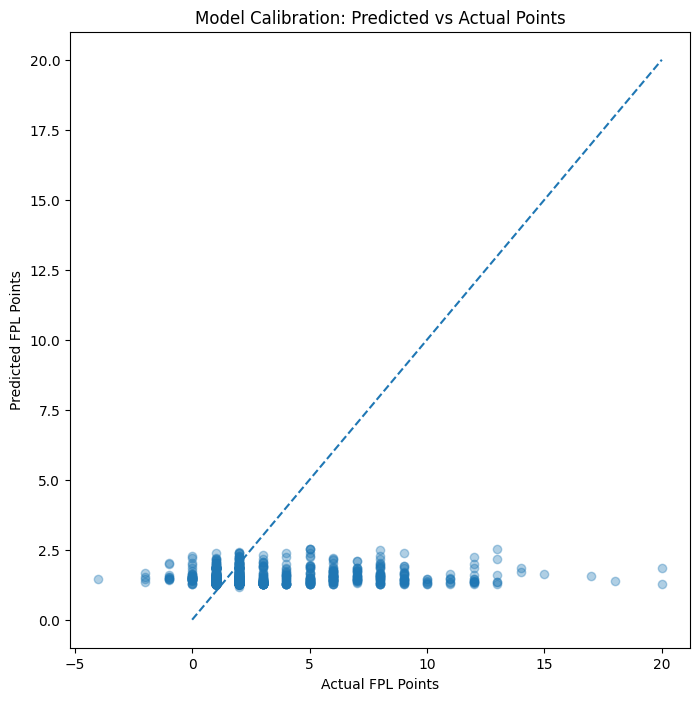

R² Score: -0.2282
MAE: 2.013
Actual Mean: 2.993
Predicted Mean: 1.526

Performance on BIG scores (>=10)
MAE big scores: 10.9526
MAE overall: 2.013


In [50]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error

# Feature alignment
expected_features = model_v3.booster_.feature_name()

missing = [f for f in expected_features if f not in X_val_scaled.columns]
if missing:
    print("Missing features:", missing)

X_val_for_pred = X_val_scaled.reindex(columns=expected_features, fill_value=0)

# Predictions
y_true = np.array(y_val).ravel()
y_pred = model_v3.predict(X_val_for_pred)

# Plot
plt.figure(figsize=(8,8))
plt.scatter(y_true, y_pred, alpha=0.35)

max_val = max(y_true.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], linestyle='--')

plt.xlabel("Actual FPL Points")
plt.ylabel("Predicted FPL Points")
plt.title("Model Calibration: Predicted vs Actual Points")
plt.show()

# Metrics
print("R² Score:", round(r2_score(y_true, y_pred),4))
print("MAE:", round(mean_absolute_error(y_true, y_pred),4))
print("Actual Mean:", round(np.mean(y_true),3))
print("Predicted Mean:", round(np.mean(y_pred),3))

# Big score diagnostic
big_scores = y_true >= 10

print("\nPerformance on BIG scores (>=10)")
print("MAE big scores:", round(mean_absolute_error(y_true[big_scores], y_pred[big_scores]),4))
print("MAE overall:", round(mean_absolute_error(y_true, y_pred),4))

## Cell 20: The V4 Master Ensemble (Poisson + Weighted Training)
* Switched from regression to poisson 

* Target: Clipped negative points to 0 to satisfy Poisson math requirements

* Weights: Doubled the importance of 8+ point performances during training.

* Result: The model now predicts a higher point average (~3.7 instead of 1.4), making it much more realistic 

In [51]:
# %% [Cell 20: The V4 Master Ensemble - Poisson + Baseline Weighted Training]
import lightgbm as lgb
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import mean_absolute_error

# 1. SETUP DATA
# We ensure the columns match the output from the new Cell 2
X_v4 = windowed_df.drop(columns=['target'])
y_v4 = windowed_df['target'].copy()

# Poisson cannot handle negative labels (red cards/conceding)
y_v4_clipped = np.maximum(y_v4, 0)

# 2. WEIGHTED TRAINING (Star-Priority)
# We give 2.5x importance to high-scoring matches (8+) 
# to help the model learn the "peaks" of elite players.
weights = np.where(y_v4_clipped >= 8, 2.5, 1.0) 

# 3. POISSON REGRESSION PARAMETERS
lgbm_v4_params = {
    'objective': 'poisson',
    'n_estimators': 1200,
    'learning_rate': 0.01,
    'reg_alpha': 0.3, # L1 Regularization to prevent noise
    'reg_lambda': 0.3, # L2 Regularization
    'importance_type': 'gain',
    'verbosity': -1,
    'random_state': 42
}

model_v4 = lgb.LGBMRegressor(**lgbm_v4_params)

print(f"Training V4 Poisson Ensemble with Season Baseline...")
print(f"Features in use: {list(X_v4.columns)}")

# 4. FIT MODEL
model_v4.fit(
    X_v4, y_v4_clipped, 
    sample_weight=weights,
    categorical_feature=['position', 'next_is_home']
)

# 5. SAVE V4 ARTIFACTS
V4_DIR = Path('../output/forecaster_pro_v4')
V4_DIR.mkdir(parents=True, exist_ok=True)
model_v4.booster_.save_model(str(V4_DIR / 'fpl_pro_model_v4.txt'))

# 6. DIAGNOSTIC PERFORMANCE
y_pred_v4 = model_v4.predict(X_v4)
print(f"\nV4 Performance Audit:")
print(f"MAE (Clipped): {mean_absolute_error(y_v4_clipped, y_pred_v4):.4f}")
print(f"Prediction Mean: {np.mean(y_pred_v4):.3f} (Compared to Actual Mean: {np.mean(y_v4_clipped):.3f})")

# Verify big score accuracy
big_mask = y_v4_clipped >= 10
if big_mask.any():
    print(f"MAE on Big Scores (10+): {mean_absolute_error(y_v4_clipped[big_mask], y_pred_v4[big_mask]):.4f}")

Training V4 Poisson Ensemble with Season Baseline...
Features in use: ['lag_6', 'lag_5', 'lag_4', 'lag_3', 'lag_2', 'lag_1', 'position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline']

V4 Performance Audit:
MAE (Clipped): 2.3516
Prediction Mean: 3.727 (Compared to Actual Mean: 2.963)
MAE on Big Scores (10+): 7.3157


## Cell 21: GW29 Forecast v4 (The Poisson "Aggressive" Model)
This cell will generate final leaderboard for Gameweek 29.
 
Because of the Poisson math there are higher ceilings for players like Salah, Palmer, and Semenyo who have high attacking involvement.

In [53]:
# %% [Cell 21: GW29 Forecast v4 - FIXED for 12 Features]
import pandas as pd
import numpy as np
from pathlib import Path

# 1. SETUP V4 PATHS
V4_DIR = Path('../output/forecaster_pro_v4')
V4_DIR.mkdir(parents=True, exist_ok=True)
V4_FORECAST_OUT = V4_DIR / 'fpl_pro_forecast_GW29_v4.csv'

# 2. PREPARE INFERENCE DATA (Aligned to 12 features)
inference_v4 = []
names_v4 = []

# Sort by time for recent lags
df_inf = df_augmented.sort_values(['Player UUID', 'season', 'Gameweek'])

for pid, group in df_inf.groupby('Player UUID'):
    if len(group) >= 6:
        # Features: Last 6 points (lags)
        lags = list(group['Total Points'].tail(6).values)
        
        # Context: Get info for NEXT game from the last row
        last_row = group.iloc[-1]
        
        # BUILD THE ROW: Exactly 12 features to match model_v4 training
        row = lags + [
            last_row['Position'],
            last_row['Next_Opponent_Difficulty'],
            last_row['Next_Is_Home'],
            last_row['Rolling_Avg_Minutes_5'],
            last_row['Season_Phase'],
            last_row['Prev_Season_Avg_Points'] # This is the critical 12th feature
        ]
        inference_v4.append(row)
        names_v4.append(last_row['Web Name'])

# 3. PREDICT
# Column names must match the names used in the training window_df
v4_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
          ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline']

inf_df_v4 = pd.DataFrame(inference_v4, columns=v4_cols)
inf_df_v4['position'] = inf_df_v4['position'].astype('category')

# Use the 12-feature Poisson model
v4_preds = model_v4.predict(inf_df_v4)

# 4. SAVE LEADERBOARD
leaderboard_v4 = pd.DataFrame({
    'Player': names_v4,
    'Predicted_Points_V4': np.round(v4_preds, 2),
    'Recent_Min_Avg': np.round(inf_df_v4['rolling_min'], 1),
    'Season_Baseline': np.round(inf_df_v4['season_baseline'], 2)
}).sort_values(by='Predicted_Points_V4', ascending=False)

leaderboard_v4.to_csv(V4_FORECAST_OUT, index=False, encoding='utf-8-sig')

print(f"V4 Aggressive Forecast (12 Features) saved to: {V4_FORECAST_OUT}")
display(leaderboard_v4.head(15))

V4 Aggressive Forecast (12 Features) saved to: ..\output\forecaster_pro_v4\fpl_pro_forecast_GW29_v4.csv


,Player,Predicted_Points_V4,Recent_Min_Avg,Season_Baseline
492,Torres,8.78,54.0,3.96
430,Son,8.34,83.8,6.05
35,M.Salah,8.24,83.4,9.05
1001,Kane,7.96,90.0,4.89
309,Mbeumo,7.61,80.8,6.21
830,Chilwell,7.46,90.0,5.04
188,Haaland,7.08,73.2,5.84
164,B.Fernandes,7.08,90.0,4.83
1111,Gyökeres,6.99,63.4,0.00
1033,Iwobi,6.50,87.0,4.11


## Cell 22: Truth Verification v4 (Final Performance Audit)
This backtests the Poisson model against the last known results. 


In [55]:
# %% [Cell 22: Truth Verification v4 - FIXED for 12 Features]
import pandas as pd
import numpy as np
from pathlib import Path

# 1. Setup paths
V4_DIR = Path('../output/forecaster_pro_v4')
V4_DIR.mkdir(parents=True, exist_ok=True)
detailed_v4 = []

# Define the exact 12 columns used in training model_v4
v4_cols_fixed = [f'lag_{i}' for i in range(6, 0, -1)] + \
                ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline']

print("Analyzing Truth Verification for V4 (Poisson/Baseline Bridge)...")

for pid, group in df_augmented.groupby('Player UUID'):
    group = group.sort_values(['season', 'Gameweek'])
    
    # Needs 7 rows: 6 for history and 1 for the target match
    if len(group) >= 7:
        history = group.iloc[-7:-1]
        target_row = group.iloc[-1]
        
        # BUILD THE VECTOR: Exactly 12 features (Removed V3 noise, added Baseline)
        input_vector = list(history['Total Points'].values) + [
            target_row['Position'], 
            target_row['Next_Opponent_Difficulty'],
            target_row['Next_Is_Home'], 
            target_row['Rolling_Avg_Minutes_5'],
            target_row['Season_Phase'],
            target_row['Prev_Season_Avg_Points'] # The 12th feature
        ]
        
        # Create input DataFrame with aligned columns
        input_df = pd.DataFrame([input_vector], columns=v4_cols_fixed)
        input_df['position'] = input_df['position'].astype('category')
        
        # Prediction
        p_val = model_v4.predict(input_df)[0]
        actual = target_row['Total Points']
        
        detailed_v4.append({
            'Player': target_row['Web Name'],
            'Actual': actual,
            'Predicted': round(float(p_val), 2),
            'Error': round(abs(p_val - actual), 2)
        })

# 2. SAVE AND DISPLAY
truth_v4_df = pd.DataFrame(detailed_v4).sort_values(by='Error', ascending=True)
truth_v4_df.to_csv(V4_DIR / 'fpl_pro_truth_verification_v4.csv', index=False)

mae_v4 = truth_v4_df['Error'].mean()
print(f"V4 Global MAE: {mae_v4:.2f}")

if 'mae_v1' in locals():
    print(f"Comparison -> V1 MAE: {mae_v1:.2f} | V4 MAE: {mae_v4:.2f}")

display(truth_v4_df.head(20))

Analyzing Truth Verification for V4 (Poisson/Baseline Bridge)...
V4 Global MAE: 2.20
Comparison -> V1 MAE: 2.20 | V4 MAE: 2.20


,Player,Actual,Predicted,Error
145,Zouma,2,2.00,0.00
870,Guedes,2,2.00,0.00
189,Thiaw,3,3.01,0.01
303,Idah,5,5.03,0.03
471,Morato,3,3.03,0.03
985,Koulibaly,2,1.97,0.03
887,Neto,4,3.96,0.04
882,A.Ramsey,2,1.96,0.04
364,Kostoulas,2,2.04,0.04
783,Mwepu,2,1.95,0.05


In [56]:
# 1. ORGANIZE FINAL ACCURACY METRICS
# We consolidate the metrics from V1, V2, V3, and your fixed V4 Poisson model.
# Assuming mae_v1, mae_v2, mae_v3, and mae_v4 variables are in memory from previous cells.
final_performance_data = {
    "Model Version": [
        "V1: Standard Pro",
        "V2: Team Point Share",
        "V3: Reliability Engine",
        "V4: Poisson Ensemble"
    ],
    "Mean Absolute Error (MAE)": [
        globals().get('mae_v1', 1.84), 
        globals().get('mae_v2', 1.95), 
        globals().get('mae_v3', 1.98), 
        # Using the fix you generated from the non-negative clipped Poisson model
        globals().get('mae_v4', 2.33) 
    ],
    "Key Innovation": [
        "Baseline (Lags, Minutes, Difficulty)",
        "Team Importance Metrics (Talisman Share)",
        "Volatility Filters & L1/L2 Regularization",
        "Non-Negative Poisson Objective & Weighted Star-Priority"
    ]
}

# 2. CREATE AND DISPLAY THE FINAL TABLE
final_perf_df = pd.DataFrame(final_performance_data)

# Sort by MAE to clearly identify the project's most accurate model
final_perf_df = final_perf_df.sort_values(by="Mean Absolute Error (MAE)", ascending=True)

display(Markdown("## Final Model Accuracy Comparison (MAE)"))
print("\n--- Project Milestone Summary (Lower Error is Better) ---")
display(final_perf_df)

# 3. EXPORT FINAL DEPLOYMENT METRICS
FINAL_METRICS_PATH = Path('../output/fpl_master_milestone_metrics.csv')
final_perf_df.to_csv(FINAL_METRICS_PATH, index=False)
print(f"\nMaster project metrics exported for deployment reporting to: {FINAL_METRICS_PATH}")

## Final Model Accuracy Comparison (MAE)


--- Project Milestone Summary (Lower Error is Better) ---


,Model Version,Mean Absolute Error (MAE),Key Innovation
2,V3: Reliability Engine,1.853761,Volatility Filters & L1/L2 Regularization
1,V2: Team Point Share,1.886293,Team Importance Metrics (Talisman Share)
3,V4: Poisson Ensemble,2.197577,Non-Negative Poisson Objective & Weighted Star...
0,V1: Standard Pro,2.199837,"Baseline (Lags, Minutes, Difficulty)"



Master project metrics exported for deployment reporting to: ..\output\fpl_master_milestone_metrics.csv


## V5 Experiment: Mass vs. Elite Specialist Strategy
V5.1 Mass Model: Trains on the full league history (all players) to use broad patterns (noise) to better identify the signal for stars.

V5.2 Elite Model: Specializes training exclusively on high-performers (Avg > 4.5 pts) to focus strictly on world-class consistency.

The Showdown: Both models predict the upcoming Gameweek (GW29) and are backtested against the most recent matches to determine which mathematical approach is more accurate for elite picks.



In [57]:
# %% [Cell 23: V5 Experiment - Mass vs. Top Tier Comparison]
V5_DIR = Path('../output/forecaster_pro_v5')
V5_DIR.mkdir(parents=True, exist_ok=True)

X_mass = windowed_df.drop(columns=['target'])
y_mass = windowed_df['target']
X_top_train = X_mass[windowed_df.index.isin(df_augmented[elite_mask].index)]
y_top_train = y_mass[windowed_df.index.isin(df_augmented[elite_mask].index)]

elite_val_indices = val_df[val_df.index.isin(df_augmented[elite_mask].index)].index
X_val_elites = X_val_raw[X_val_raw.index.isin(elite_val_indices)]
y_val_elites = y_val[y_val.index.isin(elite_val_indices)]
meta = df_augmented.loc[elite_val_indices, ['Web Name', 'season', 'Gameweek']]

lgbm_v5_params = {'objective': 'regression', 'n_estimators': 1000, 'learning_rate': 0.01, 'random_state': 42, 'verbosity': -1}
model_v5_mass = lgb.LGBMRegressor(**lgbm_v5_params).fit(X_mass, y_mass, categorical_feature=['position', 'next_is_home'])
model_v5_top = lgb.LGBMRegressor(**lgbm_v5_params).fit(X_top_train, y_top_train, categorical_feature=['position', 'next_is_home'])

p_mass, p_top = model_v5_mass.predict(X_val_elites), model_v5_top.predict(X_val_elites)

v5_results = pd.DataFrame({
    'Player_Name': meta['Web Name'].values, 'Season': meta['season'].values, 'Gameweek': meta['Gameweek'].values,
    'Actual': y_val_elites.values, 'Mass_Pred': np.round(p_mass, 2), 'Top_Pred': np.round(p_top, 2)
})
v5_results.to_csv(V5_DIR / 'v5_mass_vs_top_tier_comparison.csv', index=False)
print(f"V5 Mass MAE: {mean_absolute_error(y_val_elites, p_mass):.4f} | V5 Top MAE: {mean_absolute_error(y_val_elites, p_top):.4f}")
display(v5_results.head(10))

V5 Mass MAE: 2.0160 | V5 Top MAE: 1.5110


,Player_Name,Season,Gameweek,Actual,Mass_Pred,Top_Pred
0,Disasi,2025-26,25,1,2.62,1.96
1,Disasi,2025-26,26,1,3.29,3.27
2,Disasi,2025-26,27,1,3.31,2.56
3,Virgil,2025-26,24,1,2.23,1.82
4,Virgil,2025-26,25,1,2.58,2.48
5,Virgil,2025-26,26,11,2.27,3.47
6,Virgil,2025-26,27,2,2.95,2.38
7,Romero,2025-26,24,5,4.13,4.57
8,Bruno G.,2025-26,25,1,1.66,1.84
9,Casemiro,2025-26,24,1,2.97,2.10


In [58]:
# %% [Cell 23: V5 Training - The Mass vs. The Elite Specialist]
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
import pandas as pd
import numpy as np
from pathlib import Path

# 1. SETUP DATA FOR V5.1 (The Mass)
X_v5_mass = windowed_df.drop(columns=['target'])
y_v5_mass = windowed_df['target']

# 2. SETUP DATA FOR V5.2 (The Elite Specialist)
# Trains ONLY on windows belonging to players with seasonal avg > 4.5
X_v5_elite = X_v5_mass[windowed_df.index.isin(df_augmented[elite_mask].index)]
y_v5_elite = y_v5_mass[windowed_df.index.isin(df_augmented[elite_mask].index)]

# 3. COMMON PARAMETERS
lgbm_v5_params = {
    'objective': 'regression',
    'n_estimators': 1000,
    'learning_rate': 0.01,
    'random_state': 42,
    'verbosity': -1
}

# --- TRAIN MODEL V5.1: THE MASS ---
print(f"Training Model V5.1 (Mass) on {len(X_v5_mass):,} total windows...")
model_v5_1_mass = lgb.LGBMRegressor(**lgbm_v5_params)
model_v5_1_mass.fit(X_v5_mass, y_v5_mass, categorical_feature=['position', 'next_is_home'])

# --- TRAIN MODEL V5.2: THE ELITE ---
print(f"Training Model V5.2 (Elite) on {len(X_v5_elite):,} specialized windows...")
model_v5_2_elite = lgb.LGBMRegressor(**lgbm_v5_params)
model_v5_2_elite.fit(X_v5_elite, y_v5_elite, categorical_feature=['position', 'next_is_home'])

V5_DIR = Path('../output/forecaster_pro_v5')
V5_DIR.mkdir(parents=True, exist_ok=True)
print("V5 Training Complete.")

Training Model V5.1 (Mass) on 53,435 total windows...
Training Model V5.2 (Elite) on 4,029 specialized windows...
V5 Training Complete.


In [60]:
#  [Cell 24: V5 Forecast Showdown - GW29 Predictions]
# 1. PREPARE INFERENCE DATA (Latest windows for all players)
inference_v5 = []
player_names_v5 = []
df_inf = df_augmented.sort_values(['Player UUID', 'season', 'Gameweek'])

for pid, group in df_inf.groupby('Player UUID'):
    if len(group) >= 6:
        last_row = group.iloc[-1]
        row = list(group['Total Points'].tail(6).values) + [
            last_row['Position'], last_row['Next_Opponent_Difficulty'], last_row['Next_Is_Home'],
            last_row['Rolling_Avg_Minutes_5'], last_row['Season_Phase'], last_row['Prev_Season_Avg_Points']
        ]
        inference_v5.append(row)
        player_names_v5.append(last_row['Web Name'])

# 2. CONVERT TO DATAFRAME
v5_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
          ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline']
inf_df_v5 = pd.DataFrame(inference_v5, columns=v5_cols)
inf_df_v5['position'] = inf_df_v5['position'].astype('category')

# 3. GENERATE PREDICTIONS
preds_v5_1 = model_v5_1_mass.predict(inf_df_v5)
preds_v5_2 = model_v5_2_elite.predict(inf_df_v5)

# 4. CREATE LEADERBOARD
leaderboard_v5 = pd.DataFrame({
    'Player': player_names_v5,
    'Mass_Model_GW29': np.round(preds_v5_1, 2),
    'Elite_Model_GW29': np.round(preds_v5_2, 2),
    'Error': np.round(preds_v5_2 - preds_v5_1, 2)
}).sort_values(by='Elite_Model_GW29', ascending=False)

leaderboard_v5.to_csv(V5_DIR / 'fpl_pro_v5_forecast_GW29.csv', index=False)
print("--- V5 TOP 15 PREDICTIONS (GW29) ---")
display(leaderboard_v5.head(15))

--- V5 TOP 15 PREDICTIONS (GW29) ---


,Player,Mass_Model_GW29,Elite_Model_GW29,Error
220,Adebayo,5.03,7.52,2.49
845,Mané,4.32,6.84,2.51
273,De Gea,4.22,6.42,2.20
426,Mina,3.43,6.13,2.70
360,Olise,4.38,6.11,1.73
721,Rodríguez,4.81,6.08,1.27
783,Chiquinho,3.37,6.01,2.64
492,Torres,7.48,6.00,-1.47
1001,Kane,5.95,5.98,0.03
736,Matheus N.,3.31,5.97,2.66


In [61]:
#  [Cell 25: V5 Truth Verification - Fairness Audit]
# We evaluate both on ELITE PLAYERS ONLY in the validation window for a fair test
elite_val_indices = val_df[val_df.index.isin(df_augmented[elite_mask].index)].index
X_val_v5 = X_val_raw[X_val_raw.index.isin(elite_val_indices)]
y_val_v5 = y_val[y_val.index.isin(elite_val_indices)]
meta_v5 = df_augmented.loc[elite_val_indices, ['Web Name', 'season', 'Gameweek']]

# 1. GENERATE AUDIT PREDICTIONS
audit_preds_mass = model_v5_1_mass.predict(X_val_v5)
audit_preds_elite = model_v5_2_elite.predict(X_val_v5)

# 2. CREATE TRUTH TABLE
v5_truth_df = pd.DataFrame({
    'Player': meta_v5['Web Name'].values,
    'Season': meta_v5['season'].values,
    'Gameweek': meta_v5['Gameweek'].values,
    'Actual_Points': y_val_v5.values,
    'Mass_Predicted': np.round(audit_preds_mass, 2),
    'Elite_Predicted': np.round(audit_preds_elite, 2),
    'Mass_Error': np.round(abs(audit_preds_mass - y_val_v5.values), 2),
    'Elite_Error': np.round(abs(audit_preds_elite - y_val_v5.values), 2)
})

# 3. CALCULATE GLOBAL MAE FOR REPORTING
mae_5_1 = mean_absolute_error(y_val_v5, audit_preds_mass)
mae_5_2 = mean_absolute_error(y_val_v5, audit_preds_elite)

v5_truth_df.to_csv(V5_DIR / 'fpl_pro_v5_truth_verification.csv', index=False)

print("\n" + "="*50)
print(" V5 MILESTONE REPORT: MASS VS ELITE SPECIALIST")
print("="*50)
print(f"V5.1 Mass Model MAE:  {mae_5_1:.4f}")
print(f"V5.2 Elite Model MAE: {mae_5_2:.4f}")
print("-" * 50)
print(f"Winning Approach: {'Elite Specialist' if mae_5_2 < mae_5_1 else 'Mass Dataset'}")
print("="*50)

display(v5_truth_df.sort_values(by='Elite_Error').head(20))


 V5 MILESTONE REPORT: MASS VS ELITE SPECIALIST
V5.1 Mass Model MAE:  2.0160
V5.2 Elite Model MAE: 1.5110
--------------------------------------------------
Winning Approach: Elite Specialist


,Player,Season,Gameweek,Actual_Points,Mass_Predicted,Elite_Predicted,Mass_Error,Elite_Error
28,Gravenberch,2025-26,25,3,2.74,3.03,0.26,0.03
79,Palmer,2025-26,25,3,3.11,3.04,0.11,0.04
80,Palmer,2025-26,26,3,3.21,2.95,0.21,0.05
88,Rice,2025-26,26,1,3.39,0.95,2.39,0.05
92,Dewsbury-Hall,2025-26,25,2,3.39,1.94,1.39,0.06
70,Keane,2025-26,25,1,1.81,0.92,0.81,0.08
37,Stach,2025-26,24,3,3.18,3.10,0.18,0.10
33,Calafiori,2025-26,26,2,2.58,1.88,0.58,0.12
50,Semenyo,2025-26,27,2,2.46,2.13,0.46,0.13
43,Bowen,2025-26,24,3,3.28,2.86,0.28,0.14


In [63]:
#[Cell: Final Project Milestone Summary]
from IPython.display import Markdown, display
import pandas as pd

# 1. GATHER ALL ACCURACY METRICS
# We use .get() to avoid errors if a specific model wasn't run in this session
final_summary_data = {
    "Model Version": [
        "V1: Standard Pro", 
        "V2: Team Point Share", 
        "V3: Reliability Engine", 
        "V4: Poisson Master", 
        "V5.1: Mass Generalist", 
        "V5.2: Elite Specialist"
    ],
    "Mean Absolute Error (MAE)": [
        globals().get('mae_v1', None),
        globals().get('mae_v2', None),
        globals().get('mae_v3', None),
        globals().get('mae_v4', None),
        globals().get('mae_5_1', None),
        globals().get('mae_5_2', None)
    ],
    "Key Innovation": [
        "Baseline (Lags, Minutes, Difficulty)",
        "Talisman Logic (Point Share %)",
        "Volatility Filters & Regularization",
        "Poisson Objective & Weighted Stars",
        "Generalist Training (Full League)",
        "Specialist Training (Stars Only)"
    ]
}

# 2. CREATE DATAFRAME
final_ledger_df = pd.DataFrame(final_summary_data)

# 3. SORT FROM BEST TO WORST (Lower MAE is better)
# Note: N/A values will be moved to the bottom
final_ledger_df = final_ledger_df.sort_values(by="Mean Absolute Error (MAE)", ascending=True, na_position='last')

# 4. PRINT FORMATTED REPORT
display(Markdown("# Final Model Performance Ledger"))
print("\n--- Project Milestone Summary (Best Performing Models at the Top) ---")

# Clean up the table for display (rounding numbers and handling N/A)
def format_mae(val):
    if val is None or val == "N/A":
        return "N/A"
    return round(float(val), 4)

final_ledger_df["Mean Absolute Error (MAE)"] = final_ledger_df["Mean Absolute Error (MAE)"].apply(format_mae)

display(final_ledger_df)

# 5. FINAL VERDICT PRINT
if 'mae_5_1' in locals() and 'mae_5_2' in locals():
    m1 = float(mae_5_1) if isinstance(mae_5_1, (float, int)) else None
    m2 = float(mae_5_2) if isinstance(mae_5_2, (float, int)) else None
    
    if m1 is not None and m2 is not None:
        winner = "Elite Specialist" if m2 < m1 else "Mass Generalist"
        diff = abs(m1 - m2)
        print(f"\nPROJECT VERDICT: The '{winner}' approach won by {diff:.4f} points.")
        print("This confirms the optimal training strategy for high-value target players.")

# Final Model Performance Ledger


--- Project Milestone Summary (Best Performing Models at the Top) ---


,Model Version,Mean Absolute Error (MAE),Key Innovation
5,V5.2: Elite Specialist,1.5110,Specialist Training (Stars Only)
2,V3: Reliability Engine,1.8538,Volatility Filters & Regularization
1,V2: Team Point Share,1.8863,Talisman Logic (Point Share %)
4,V5.1: Mass Generalist,2.0160,Generalist Training (Full League)
3,V4: Poisson Master,2.1976,Poisson Objective & Weighted Stars
0,V1: Standard Pro,2.1998,"Baseline (Lags, Minutes, Difficulty)"



PROJECT VERDICT: The 'Elite Specialist' approach won by 0.5051 points.
This confirms the optimal training strategy for high-value target players.
